# 080 — Planar array analysis

Apply a joint three-channel plane-wave coherence search to all 153 fixed
baseline-corrected final-event Streams produced by Notebook 0700. Continuous
coherence, correlation, surface-width, and window-stability metrics are
retained for every event; quality thresholds are applied only after inversion.

Surface widths describe the sampled score surface; window dispersion measures
repeatability under the stated perturbations. Neither includes coordinate
uncertainty or is a confidence interval. A fine-grid-edge optimum can truncate
reported surface widths. The principal row 13 is a representative catalogue
entry, not a resolved mapping of the entire physical explosion complex.

Reported nominal azimuths use EPSG:32617 grid north. Geographic bearings
are approximately grid bearings plus the local meridian convergence. The
geometric comparison line retains the configured seismometer reference but
is converted to grid north; its reference point differs from the array centroid.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

OUTPUT_ROOT = config.NB080_DIR
LAST_OUTPUT_ROOT = config.NB070_DIR
DERIVED_DIR = LAST_OUTPUT_ROOT / "derived"
EVENT_STREAMS_DIR = LAST_OUTPUT_ROOT / "event_streams"

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"

for required_file in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()
if not GEOMETRY_FILE.exists():
    raise FileNotFoundError(
        "Geometry product recorded by Notebook 010 was not found: "
        f"{GEOMETRY_FILE}"
    )
weather_rows = pd.read_csv(WEATHER_SUMMARY_FILE)
if len(weather_rows) != 1:
    raise ValueError("Expected one adopted weather-summary row")
weather_summary = weather_rows.iloc[0]
if analysis_config["infrasound_reference_channel"] != "DD2":
    raise ValueError("This planar implementation requires the configured DD2 reference")
SOURCE_REDUCTION_SPEED_MPS = 351.0

CANDIDATE_CATALOGUE_OVERRIDE: Path | None = None
EVENT_STREAM_DIR_OVERRIDE: Path | None = None
GEOMETRY_FILE_OVERRIDE: Path | None = None

# Permissive eligibility: analyze weak candidates rather than rejecting them before
# the array has a chance to test coherence.
ANALYSIS_MIN_STACK_PEAK_TO_PEAK_PA = 10.0
ANALYSIS_MIN_STACK_SNR = 1.5
ANALYSIS_MIN_CHANNEL_COUNT = 2
REQUIRE_VALID_MEASUREMENT_FOR_ANALYSIS = True

# Preserve the original thresholds as a descriptive core-catalogue label.
CORE_MIN_STACK_PEAK_TO_PEAK_PA = 25.0
CORE_MIN_STACK_SNR = 3.0
CORE_MIN_CHANNEL_COUNT = 2

# Named complex events bypass the short-pulse morphology requirement.
PRINCIPAL_EXPLOSION_EVENT_NUMBER = 13
FORCE_INCLUDE_EVENT_NUMBERS = (PRINCIPAL_EXPLOSION_EVENT_NUMBER,)
EVENT_LABELS = {PRINCIPAL_EXPLOSION_EVENT_NUMBER: "principal_first_stage_explosion"}

# Coarse plane-wave search: array -> source back azimuth, clockwise from north.
BACK_AZIMUTH_MIN_DEG = 180.0
BACK_AZIMUTH_MAX_DEG = 220.0
BACK_AZIMUTH_STEP_DEG = 0.5
APPARENT_SPEED_MIN_MPS = 280.0
APPARENT_SPEED_MAX_MPS = 440.0
APPARENT_SPEED_STEP_MPS = 2.0

# Event-specific refinement around the coarse maximum.
FINE_AZIMUTH_HALF_WIDTH_DEG = 2.0
FINE_AZIMUTH_STEP_DEG = 0.1
FINE_SPEED_HALF_WIDTH_MPS = 20.0
FINE_SPEED_STEP_MPS = 0.5

EXPECTED_SLC40_BACK_AZIMUTH_DEG = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)
PROVISIONAL_EFFECTIVE_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)
ARRAY_TO_SOURCE_REFERENCE_RANGE_M = float(
    analysis_config["array_reference"]["distance_m"]
)

# Event-specific score windows relative to the reduced/reference time (normally DD2).
DEFAULT_SCORE_WINDOW_RELATIVE_S = (-0.040, 0.180)
CUSTOM_SCORE_WINDOWS = {
    PRINCIPAL_EXPLOSION_EVENT_NUMBER: (-0.040, 0.350),
}
SCORE_WEIGHT_SEMBLANCE = 0.60
MAX_RESIDUAL_LAG_S = 0.040

# Descriptive near-maximum surface widths. These are not confidence intervals.
CONSTRAINT_SCORE_DROPS = (0.01, 0.02)

# Window-stability perturbations around each event's own scoring interval.
STABILITY_WINDOW_SHIFTS_S = (-0.008, 0.0, 0.008)
STABILITY_DURATION_FACTORS = (0.90, 1.0, 1.10)
STABILITY_LOCAL_AZIMUTH_HALF_WIDTH_DEG = 2.0
STABILITY_LOCAL_SPEED_HALF_WIDTH_MPS = 20.0
STABILITY_AZIMUTH_STEP_DEG = 0.1
STABILITY_SPEED_STEP_MPS = 0.5
RUN_WINDOW_STABILITY = True
# Stability is only needed to distinguish A/B solutions. Events below the B
# coherence threshold are C by definition, so do not spend most of the runtime
# perturbing their windows.
RUN_WINDOW_STABILITY_MIN_SCORE = QUALITY_B_MIN_SCORE if "QUALITY_B_MIN_SCORE" in globals() else 0.75

# Robust batch behaviour.
MIN_VALID_SCORE_SAMPLES = 5
MIN_VALID_WINDOW_FRACTION = 0.50
# A clean final run must not reuse checkpoints made with reconstructed-event
# numbering or the former short segments. Enable only after this version has
# created a new checkpoint.
RESUME_FROM_CHECKPOINT = False
CHECKPOINT_FILE = OUTPUT_ROOT / "planar_array_results_checkpoint.csv"
FAILURE_FILE = OUTPUT_ROOT / "planar_array_failures.csv"

# Provisional descriptive quality classes; retain continuous metrics in all exports.
QUALITY_A_MIN_SCORE = 0.90
QUALITY_A_MAX_AZIMUTH_STD_DEG = 0.5
QUALITY_A_MAX_SPEED_STD_MPS = 3.0
QUALITY_B_MIN_SCORE = 0.75
QUALITY_B_MAX_AZIMUTH_STD_DEG = 1.0
QUALITY_B_MAX_SPEED_STD_MPS = 8.0
RUN_WINDOW_STABILITY_MIN_SCORE = QUALITY_B_MIN_SCORE

# Figure display zoom. The broad search remains wider than this view.
DISPLAY_AZIMUTH_MIN_DEG = 195.0
DISPLAY_AZIMUTH_MAX_DEG = 207.0
DISPLAY_SPEED_MIN_MPS = 300.0
DISPLAY_SPEED_MAX_MPS = 400.0

MAX_EVENTS: int | None = None

FIGURE_DIR = OUTPUT_ROOT / "event_figures"
SURFACE_DIR = OUTPUT_ROOT / "surfaces"
COMPOSITE_DIR = OUTPUT_ROOT / "composites"
for directory in (OUTPUT_ROOT, FIGURE_DIR, SURFACE_DIR, COMPOSITE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path
from typing import Any, Iterable, Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from obspy import Stream, Trace, UTCDateTime, read
from scipy.signal import correlate, correlation_lags

CHANNELS = ("DD1", "DD2", "DD3")


def first_existing(paths: Iterable[Path], *, label: str) -> Path:
    checked = []
    for path in paths:
        path = Path(path).expanduser()
        checked.append(path)
        if path.exists():
            return path.resolve()
    lines = "\n".join(f"  {path}" for path in checked)
    raise FileNotFoundError(f"Could not locate {label}. Checked:\n{lines}")


def choose_column(frame: pd.DataFrame, candidates: Iterable[str], *, required=True):
    for name in candidates:
        if name in frame.columns:
            return name
    if required:
        raise KeyError(
            "None of the expected columns were found: "
            f"{list(candidates)}. Available columns: {frame.columns.tolist()}"
        )
    return None


def event_number_column(frame: pd.DataFrame) -> str:
    return choose_column(
        frame,
        ["final_event_number", "event_number", "candidate_event_number",
         "reconstructed_event_number", "eventNumber"],
    )


def normalize_event_catalogue(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    source = event_number_column(out)
    if source != "event_number":
        out = out.rename(columns={source: "event_number"})
    out["event_number"] = pd.to_numeric(out["event_number"], errors="raise").astype(int)
    if out["event_number"].duplicated().any():
        duplicates = out.loc[out["event_number"].duplicated(), "event_number"].tolist()
        raise ValueError(f"Duplicate final event numbers: {duplicates}")
    return out.sort_values("event_number").reset_index(drop=True)


def resolve_event_time_column(frame: pd.DataFrame) -> str:
    return choose_column(
        frame,
        [
            "reduced_event_epoch_s",
            "reduced_event_time_epoch_s",
            "event_time_epoch_s",
            "reference_time_epoch_s",
            "median_reduced_pick_epoch_s",
            "first_reduced_pick_epoch_s",
            "arrivalTimeEpochS",
        ],
    )


def locate_event_stream(event_row: pd.Series, event_stream_dir: Path) -> Path:
    for column in ("stream_file", "event_stream_file", "pickle_file", "stream_path"):
        if column in event_row.index and pd.notna(event_row[column]):
            candidate = Path(str(event_row[column])).expanduser()
            if not candidate.is_absolute():
                candidate = event_stream_dir / candidate
            if candidate.exists():
                return candidate.resolve()

    event_number = int(event_row["event_number"])
    patterns = [
        f"event_{event_number:03d}.pkl",
        f"event_{event_number:03d}_*.pkl",
        f"candidate_event_{event_number:03d}.pkl",
        f"*event*{event_number:03d}*.pkl",
    ]
    matches = []
    for pattern in patterns:
        matches.extend(event_stream_dir.glob(pattern))
    matches = sorted({path.resolve() for path in matches})
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one Pickle stream for event {event_number}; found {len(matches)}: {matches}"
        )
    return matches[0]


def load_event_stream(event_row: pd.Series, event_stream_dir: Path) -> tuple[Path, Stream]:
    path = locate_event_stream(event_row, event_stream_dir)
    stream = read(str(path), format="PICKLE")
    return path, stream


def unique_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one {channel} trace; found {len(matches)}: {[tr.id for tr in matches]}"
        )
    return matches[0]


def robust_sigma(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    median = np.median(values)
    sigma = 1.4826 * np.median(np.abs(values - median))
    if sigma <= 0:
        sigma = float(np.std(values))
    return float(sigma)


def common_sampling_rate(stream: Stream, channels=CHANNELS) -> float:
    rates = [float(unique_trace(stream, channel).stats.sampling_rate) for channel in channels]
    if not np.allclose(rates, rates[0]):
        raise ValueError(f"Infrasound sampling rates differ: {rates}")
    return rates[0]


def interpolate_trace_epoch(trace: Trace, epoch_s: np.ndarray) -> np.ndarray:
    start = float(trace.stats.starttime.timestamp)
    sampling_rate = float(trace.stats.sampling_rate)
    source_epoch = start + np.arange(trace.stats.npts, dtype=float) / sampling_rate
    values = np.asarray(trace.data, dtype=float)
    return np.interp(epoch_s, source_epoch, values, left=np.nan, right=np.nan)


def normalized_rows(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    centered = values - np.nanmedian(values, axis=1, keepdims=True)
    rms = np.sqrt(np.nanmean(centered**2, axis=1, keepdims=True))
    rms[~np.isfinite(rms) | (rms <= 0)] = np.nan
    return centered / rms


def coherence_metrics(aligned: np.ndarray, *, score_weight_semblance: float) -> dict[str, float]:
    aligned = np.asarray(aligned, dtype=float)
    finite_columns = np.all(np.isfinite(aligned), axis=0)
    aligned = aligned[:, finite_columns]
    if aligned.shape[1] < 5:
        return {
            "semblance": np.nan,
            "mean_pairwise_correlation": np.nan,
            "median_pairwise_correlation": np.nan,
            "minimum_pairwise_correlation": np.nan,
            "coherence_score": np.nan,
            "n_samples": int(aligned.shape[1]),
        }

    normalized = normalized_rows(aligned)
    if not np.all(np.isfinite(normalized)):
        return {
            "semblance": np.nan,
            "mean_pairwise_correlation": np.nan,
            "median_pairwise_correlation": np.nan,
            "minimum_pairwise_correlation": np.nan,
            "coherence_score": np.nan,
            "n_samples": int(aligned.shape[1]),
        }

    n_channels = normalized.shape[0]
    numerator = np.sum(np.sum(normalized, axis=0) ** 2)
    denominator = n_channels * np.sum(normalized**2)
    semblance = float(numerator / denominator) if denominator > 0 else np.nan

    correlations = []
    for i in range(n_channels):
        for j in range(i + 1, n_channels):
            correlations.append(float(np.corrcoef(normalized[i], normalized[j])[0, 1]))
    correlations = np.asarray(correlations, dtype=float)
    mean_corr = float(np.nanmean(correlations))
    median_corr = float(np.nanmedian(correlations))
    minimum_corr = float(np.nanmin(correlations))
    correlation_01 = np.clip((mean_corr + 1.0) / 2.0, 0.0, 1.0)
    score = score_weight_semblance * semblance + (1.0 - score_weight_semblance) * correlation_01
    return {
        "semblance": semblance,
        "mean_pairwise_correlation": mean_corr,
        "median_pairwise_correlation": median_corr,
        "minimum_pairwise_correlation": minimum_corr,
        "coherence_score": float(score),
        "n_samples": int(aligned.shape[1]),
    }


def aligned_waveforms(
    stream: Stream,
    *,
    reference_epoch_s: float,
    relative_delays_s: Mapping[str, float],
    window_relative_s: tuple[float, float],
    channels=CHANNELS,
) -> tuple[np.ndarray, np.ndarray]:
    sampling_rate = common_sampling_rate(stream, channels)
    dt = 1.0 / sampling_rate
    relative_time = np.arange(window_relative_s[0], window_relative_s[1] + 0.5 * dt, dt)
    rows = []
    for channel in channels:
        trace = unique_trace(stream, channel)
        sample_epoch = reference_epoch_s + relative_time + float(relative_delays_s[channel])
        rows.append(interpolate_trace_epoch(trace, sample_epoch))
    values = np.vstack(rows)
    finite_columns = np.all(np.isfinite(values), axis=0)
    return relative_time[finite_columns], values[:, finite_columns]


def stream_relative_coverage(
    stream: Stream,
    reference_epoch_s: float,
    channels=CHANNELS,
) -> tuple[float, float]:
    """Common zero-delay waveform coverage relative to the event reference time."""
    starts = []
    ends = []
    for channel in channels:
        trace = unique_trace(stream, channel)
        starts.append(float(trace.stats.starttime.timestamp) - reference_epoch_s)
        ends.append(float(trace.stats.endtime.timestamp) - reference_epoch_s)
    return max(starts), min(ends)


def delay_envelope(
    azimuth_grid: np.ndarray,
    speed_grid: np.ndarray,
    channels=CHANNELS,
) -> dict[str, tuple[float, float]]:
    """Min/max plane-wave delays for each channel over a search grid."""
    envelope = {channel: [np.inf, -np.inf] for channel in channels}
    for back_azimuth in azimuth_grid:
        for speed in speed_grid:
            delays = planar_relative_delays(float(back_azimuth), float(speed))
            for channel in channels:
                value = float(delays[channel])
                envelope[channel][0] = min(envelope[channel][0], value)
                envelope[channel][1] = max(envelope[channel][1], value)
    return {
        channel: (float(bounds[0]), float(bounds[1]))
        for channel, bounds in envelope.items()
    }


def clip_score_window_to_coverage(
    stream: Stream,
    reference_epoch_s: float,
    requested_window: tuple[float, float],
    *,
    delay_bounds: Mapping[str, tuple[float, float]],
    min_samples: int = MIN_VALID_SCORE_SAMPLES,
    min_fraction: float = MIN_VALID_WINDOW_FRACTION,
    channels=CHANNELS,
) -> tuple[tuple[float, float] | None, dict[str, float]]:
    """Clip a requested window to coverage valid for every channel/search delay.

    Returns None when too little waveform remains for a scientifically useful
    coherence estimate.
    """
    requested_start, requested_end = map(float, requested_window)
    requested_duration = requested_end - requested_start
    sampling_rate = common_sampling_rate(stream, channels)

    allowed_start = -np.inf
    allowed_end = np.inf
    for channel in channels:
        trace = unique_trace(stream, channel)
        trace_start = float(trace.stats.starttime.timestamp) - reference_epoch_s
        trace_end = float(trace.stats.endtime.timestamp) - reference_epoch_s
        delay_min, delay_max = delay_bounds[channel]
        # Require reference + t + delay to remain inside the trace for every
        # delay tested in the search grid.
        allowed_start = max(allowed_start, trace_start - delay_min)
        allowed_end = min(allowed_end, trace_end - delay_max)

    clipped_start = max(requested_start, allowed_start)
    clipped_end = min(requested_end, allowed_end)
    clipped_duration = max(0.0, clipped_end - clipped_start)
    n_samples = int(np.floor(clipped_duration * sampling_rate)) + 1 if clipped_duration > 0 else 0
    fraction = clipped_duration / requested_duration if requested_duration > 0 else 0.0

    info = {
        "requested_window_start_s": requested_start,
        "requested_window_end_s": requested_end,
        "usable_window_start_s": clipped_start,
        "usable_window_end_s": clipped_end,
        "usable_window_fraction": fraction,
        "usable_window_n_samples": n_samples,
    }

    if (
        clipped_end <= clipped_start
        or n_samples < int(min_samples)
        or fraction < float(min_fraction)
    ):
        return None, info

    return (clipped_start, clipped_end), info


def pairwise_diagnostics(aligned: np.ndarray, sampling_rate_hz: float, max_residual_lag_s: float):
    aligned = np.asarray(aligned, dtype=float)
    n = aligned.shape[0]
    corr_matrix = np.eye(n, dtype=float)
    lag_matrix = np.zeros((n, n), dtype=float)
    max_lag_samples = max(1, int(round(max_residual_lag_s * sampling_rate_hz)))

    for i in range(n):
        for j in range(i + 1, n):
            x = aligned[i] - np.nanmedian(aligned[i])
            y = aligned[j] - np.nanmedian(aligned[j])
            finite = np.isfinite(x) & np.isfinite(y)
            x = x[finite]
            y = y[finite]
            if len(x) < 5 or np.linalg.norm(x) == 0 or np.linalg.norm(y) == 0:
                corr = np.nan
                lag_s = np.nan
            else:
                cc = correlate(x, y, mode="full", method="auto")
                lags = correlation_lags(len(x), len(y), mode="full")
                keep = np.abs(lags) <= max_lag_samples
                cc = cc[keep] / (np.linalg.norm(x) * np.linalg.norm(y))
                lags = lags[keep]
                index = int(np.nanargmax(cc))
                corr = float(cc[index])
                lag_s = float(lags[index] / sampling_rate_hz)
            corr_matrix[i, j] = corr_matrix[j, i] = corr
            lag_matrix[i, j] = lag_s
            lag_matrix[j, i] = -lag_s

    closure_s = float(lag_matrix[0, 1] + lag_matrix[1, 2] + lag_matrix[2, 0])
    return corr_matrix, lag_matrix, closure_s


def polar_surface_plot(
    azimuth_deg: np.ndarray,
    speed_mps: np.ndarray,
    score_surface: np.ndarray,
    *,
    best_azimuth_deg: float,
    best_speed_mps: float,
    expected_azimuth_deg: float | None,
    expected_speed_mps: float | None,
    title: str,
    outfile: Path,
):
    theta = np.deg2rad(azimuth_deg)
    fig, ax = plt.subplots(figsize=(8.2, 7.2), subplot_kw={"projection": "polar"})
    mesh = ax.pcolormesh(theta, speed_mps, score_surface.T, shading="auto", cmap="viridis")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.plot(np.deg2rad(best_azimuth_deg), best_speed_mps, "*", ms=15, color="white", mec="black", label="Best")
    if expected_azimuth_deg is not None and expected_speed_mps is not None:
        ax.plot(
            np.deg2rad(expected_azimuth_deg), expected_speed_mps,
            "o", ms=7, color="orange", mec="black", label="SLC-40 / provisional speed"
        )
    ax.set_title(title, pad=22)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
    fig.colorbar(mesh, ax=ax, pad=0.12, label="Joint coherence score")
    fig.savefig(outfile, dpi=220, bbox_inches="tight")
    plt.close(fig)



def boolean_series(values: pd.Series) -> pd.Series:
    """Parse booleans robustly from native bool, numeric, or CSV text columns."""
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False)
    if pd.api.types.is_numeric_dtype(values):
        return values.fillna(0).astype(float).ne(0)
    normalized = values.astype("string").str.strip().str.lower()
    return normalized.isin({"true", "t", "yes", "y", "1"})


def event_score_window(event_number: int) -> tuple[float, float]:
    return tuple(CUSTOM_SCORE_WINDOWS.get(int(event_number), DEFAULT_SCORE_WINDOW_RELATIVE_S))


def wrapped_angle_difference_deg(angle_deg, reference_deg):
    return (np.asarray(angle_deg, dtype=float) - float(reference_deg) + 180.0) % 360.0 - 180.0


def score_surface_constraints(
    azimuth_deg: np.ndarray,
    speed_mps: np.ndarray,
    score_surface: np.ndarray,
    *,
    drops=CONSTRAINT_SCORE_DROPS,
) -> dict[str, float | bool]:
    """Describe surface concentration; widths are descriptive, not confidence intervals."""
    surface = np.asarray(score_surface, dtype=float)
    maximum = float(np.nanmax(surface))
    best_flat = int(np.nanargmax(surface))
    best_az_index, best_speed_index = np.unravel_index(best_flat, surface.shape)
    azimuth_profile = np.nanmax(surface, axis=1)
    speed_profile = np.nanmax(surface, axis=0)
    metrics = {
        "surface_maximum": maximum,
        "surface_median": float(np.nanmedian(surface)),
        "surface_p95": float(np.nanpercentile(surface, 95)),
        "peak_minus_surface_median": maximum - float(np.nanmedian(surface)),
        "peak_minus_surface_p95": maximum - float(np.nanpercentile(surface, 95)),
        "best_on_azimuth_edge": bool(best_az_index in {0, len(azimuth_deg) - 1}),
        "best_on_speed_edge": bool(best_speed_index in {0, len(speed_mps) - 1}),
    }
    azimuth_step = float(np.median(np.diff(azimuth_deg)))
    speed_step = float(np.median(np.diff(speed_mps)))
    for drop in drops:
        suffix = str(drop).replace(".", "p")
        threshold = maximum - float(drop)
        azimuth_keep = np.flatnonzero(azimuth_profile >= threshold)
        speed_keep = np.flatnonzero(speed_profile >= threshold)
        surface_keep = np.isfinite(surface) & (surface >= threshold)
        metrics[f"azimuth_width_drop_{suffix}_deg"] = (
            float(azimuth_deg[azimuth_keep[-1]] - azimuth_deg[azimuth_keep[0]])
            if azimuth_keep.size else np.nan
        )
        metrics[f"speed_width_drop_{suffix}_mps"] = (
            float(speed_mps[speed_keep[-1]] - speed_mps[speed_keep[0]])
            if speed_keep.size else np.nan
        )
        metrics[f"surface_area_drop_{suffix}_deg_mps"] = (
            float(np.count_nonzero(surface_keep) * azimuth_step * speed_step)
        )
    return metrics


def refined_grids(coarse_solution):
    azimuth_grid = np.arange(
        max(BACK_AZIMUTH_MIN_DEG, coarse_solution["best_azimuth_deg"] - FINE_AZIMUTH_HALF_WIDTH_DEG),
        min(BACK_AZIMUTH_MAX_DEG, coarse_solution["best_azimuth_deg"] + FINE_AZIMUTH_HALF_WIDTH_DEG)
        + 0.5 * FINE_AZIMUTH_STEP_DEG,
        FINE_AZIMUTH_STEP_DEG,
    )
    speed_grid = np.arange(
        max(APPARENT_SPEED_MIN_MPS, coarse_solution["best_speed_mps"] - FINE_SPEED_HALF_WIDTH_MPS),
        min(APPARENT_SPEED_MAX_MPS, coarse_solution["best_speed_mps"] + FINE_SPEED_HALF_WIDTH_MPS)
        + 0.5 * FINE_SPEED_STEP_MPS,
        FINE_SPEED_STEP_MPS,
    )
    return azimuth_grid, speed_grid


def refined_polar_plot(
    azimuth_deg,
    speed_mps,
    score_surface,
    *,
    best_azimuth_deg,
    best_speed_mps,
    expected_azimuth_deg,
    expected_speed_mps,
    title,
    outfile,
    zoom=False,
):
    theta = np.deg2rad(azimuth_deg)
    fig, ax = plt.subplots(figsize=(8.2, 7.2), subplot_kw={"projection": "polar"})
    mesh = ax.pcolormesh(theta, speed_mps, np.asarray(score_surface).T, shading="auto", cmap="viridis")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.plot(np.deg2rad(best_azimuth_deg), best_speed_mps, "*", ms=15, color="white", mec="black", label="Best")
    ax.plot(np.deg2rad(expected_azimuth_deg), expected_speed_mps, "o", ms=7, color="orange", mec="black", label="SLC-40 / 351 m s$^{-1}$")
    if zoom:
        ax.set_thetamin(DISPLAY_AZIMUTH_MIN_DEG)
        ax.set_thetamax(DISPLAY_AZIMUTH_MAX_DEG)
        ax.set_ylim(DISPLAY_SPEED_MIN_MPS, DISPLAY_SPEED_MAX_MPS)
    ax.set_title(title, pad=22)
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.12))
    fig.colorbar(mesh, ax=ax, pad=0.12, label="Joint coherence score")
    fig.savefig(outfile, dpi=220, bbox_inches="tight")
    plt.close(fig)


def rectangular_surface_plot(
    azimuth_deg,
    speed_mps,
    score_surface,
    *,
    best_azimuth_deg,
    best_speed_mps,
    title,
    outfile,
):
    fig, ax = plt.subplots(figsize=(8.8, 5.8), constrained_layout=True)
    mesh = ax.pcolormesh(azimuth_deg, speed_mps, np.asarray(score_surface).T, shading="auto", cmap="viridis")
    ax.plot(best_azimuth_deg, best_speed_mps, "*", ms=14, color="white", mec="black")
    ax.axvline(EXPECTED_SLC40_BACK_AZIMUTH_DEG, color="orange", ls="--", lw=1)
    ax.axhline(PROVISIONAL_EFFECTIVE_SPEED_MPS, color="orange", ls=":", lw=1)
    ax.set(xlabel="Back azimuth from grid north (°)", ylabel="Apparent speed (m s$^{-1}$)", title=title)
    fig.colorbar(mesh, ax=ax, label="Joint coherence score")
    fig.savefig(outfile, dpi=220, bbox_inches="tight")
    plt.close(fig)


def event_time_utc(epoch_s):
    return pd.to_datetime(float(epoch_s), unit="s", utc=True)


## Locate Notebook 070 products and normalize their schema

Epoch seconds remain authoritative. The final-event table supplies reduced event
times and links to fixed, unfiltered, moving-median-baseline-corrected event Streams.


In [3]:
candidate_catalogue_file = (
    CANDIDATE_CATALOGUE_OVERRIDE.resolve()
    if CANDIDATE_CATALOGUE_OVERRIDE is not None
    else first_existing(
        [
            DERIVED_DIR / "final_event_waveform_products.csv",
            DERIVED_DIR / "candidate_airwave_event_catalogue.csv",
            DERIVED_DIR / "candidate_event_catalogue.csv",
            DERIVED_DIR / "candidate_airwave_events.csv",
        ],
        label="Notebook 070 final-event waveform products",
    )
)
event_stream_dir = (
    EVENT_STREAM_DIR_OVERRIDE.resolve()
    if EVENT_STREAM_DIR_OVERRIDE is not None
    else first_existing(
        [EVENT_STREAMS_DIR, candidate_catalogue_file.parent / "event_streams"],
        label="Notebook 070 event-stream directory",
    )
)
candidate_events = normalize_event_catalogue(pd.read_csv(candidate_catalogue_file))
event_time_column = resolve_event_time_column(candidate_events)
print("Final-event products:", candidate_catalogue_file)
print("Event streams:", event_stream_dir)
print("Reference-time column:", event_time_column)
print("Final events:", len(candidate_events))
if len(candidate_events) != 153:
    raise RuntimeError(f"Expected 153 final events; found {len(candidate_events)}")
display(candidate_events.head())


Final-event products: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/070_prepare_event_waveform_products/derived/final_event_waveform_products.csv
Event streams: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/070_prepare_event_waveform_products/event_streams
Reference-time column: reduced_event_epoch_s
Final events: 153


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,...,noise_scale_pa,boundary_threshold_pa,start_boundary_method,end_boundary_method,morphology_class,quality_class,segment_file,segment_path,segment_start_epoch_s,segment_end_epoch_s
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.002107,3,3,"DD1,DD2,DD3","198,193,194",1.472735e+09,...,1.313656,2.627311,noise_threshold,model,robust_impulsive,robust_impulsive,candidate_event_001.pkl,/Users/glennthompson/Developer/KSCRocketSeismo...,1.472735e+09,1.472735e+09
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.011107,3,3,"DD1,DD2,DD3","201,199,200",1.472735e+09,...,1.735364,3.470728,model,model,robust_impulsive,robust_impulsive,candidate_event_002.pkl,/Users/glennthompson/Developer/KSCRocketSeismo...,1.472735e+09,1.472735e+09
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003760,3,3,"DD1,DD2,DD3","204,202,203",1.472735e+09,...,10.364551,20.729103,noise_threshold,noise_threshold,weak_impulsive,weak_impulsive,candidate_event_003.pkl,/Users/glennthompson/Developer/KSCRocketSeismo...,1.472735e+09,1.472735e+09
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.029866,2,2,"DD2,DD3","206,205",1.472735e+09,...,13.093730,26.187461,noise_threshold,noise_threshold,weak_impulsive,weak_impulsive,candidate_event_004.pkl,/Users/glennthompson/Developer/KSCRocketSeismo...,1.472735e+09,1.472735e+09
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.000866,2,2,"DD2,DD3","207,208",1.472735e+09,...,10.805127,21.610254,noise_threshold,noise_threshold,weak_impulsive,weak_impulsive,candidate_event_005.pkl,/Users/glennthompson/Developer/KSCRocketSeismo...,1.472735e+09,1.472735e+09


## Load surveyed BCHH geometry

Relative plane-wave delays are independent of the arbitrary coordinate origin. The
three-sensor centroid is used here; SLC-40 direction is retained as an external
reference rather than imposed on the inversion.


In [4]:
geometry_file = (
    GEOMETRY_FILE_OVERRIDE.resolve()
    if GEOMETRY_FILE_OVERRIDE is not None
    else GEOMETRY_FILE.resolve()
)

if not geometry_file.exists():
    raise FileNotFoundError(
        f"BCHH geometry table not found: {geometry_file}"
    )

geometry = pd.read_csv(geometry_file)
channel_column = choose_column(geometry, ["channel", "sensor", "label"])
geometry[channel_column] = geometry[channel_column].astype(str).str.upper()

east_column = choose_column(geometry, ["easting", "easting_m", "x_m"], required=False)
north_column = choose_column(geometry, ["northing", "northing_m", "y_m"], required=False)

if east_column is None or north_column is None:
    lon_column = choose_column(geometry, ["longitude", "lon"])
    lat_column = choose_column(geometry, ["latitude", "lat"])
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32617", always_xy=True)
    east, north = transformer.transform(
        geometry[lon_column].to_numpy(float),
        geometry[lat_column].to_numpy(float),
    )
    geometry["easting_m"] = east
    geometry["northing_m"] = north
    east_column, north_column = "easting_m", "northing_m"

rows = []
for channel in CHANNELS:
    matches = geometry.loc[geometry[channel_column] == channel]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one geometry row for {channel}; found {len(matches)}"
        )
    row = matches.iloc[0]
    rows.append({
        "channel": channel,
        "east_m": float(row[east_column]),
        "north_m": float(row[north_column]),
    })

array_geometry = pd.DataFrame(rows).set_index("channel")
array_geometry[["east_relative_m", "north_relative_m"]] = (
    array_geometry[["east_m", "north_m"]]
    - array_geometry[["east_m", "north_m"]].mean(axis=0)
)
if not np.isfinite(array_geometry[["east_m", "north_m"]].to_numpy()).all():
    raise ValueError("Nonfinite sensor coordinates")

# Nominal inversion azimuths use UTM grid north. Convert the geographic
# seismometer-reference comparison line to that same north convention.
from pyproj import Proj, Transformer
centroid_east = float(array_geometry.east_m.mean())
centroid_north = float(array_geometry.north_m.mean())
centroid_lon, centroid_lat = Transformer.from_crs("EPSG:32617", "EPSG:4326", always_xy=True).transform(centroid_east, centroid_north)
GRID_CONVERGENCE_DEG = float(Proj("EPSG:32617").get_factors(centroid_lon, centroid_lat).meridian_convergence)
CONFIGURED_GEOGRAPHIC_BAZ_DEG = float(analysis_config["array_reference"]["back_azimuth_to_slc40_deg"])
EXPECTED_SLC40_BACK_AZIMUTH_DEG = (CONFIGURED_GEOGRAPHIC_BAZ_DEG - GRID_CONVERGENCE_DEG) % 360
print("Comparison line uses seismometer-reference geographic bearing converted to grid north")
print("Geometry:", geometry_file)
display(array_geometry)


Comparison line uses seismometer-reference geographic bearing converted to grid north
Geometry: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_channels.csv


,east_m,north_m,east_relative_m,north_relative_m
channel,,,,
DD1,541816.300901,3.160889e+06,0.660572,20.519836
DD2,541828.276924,3.160851e+06,12.636595,-17.151704
DD3,541802.343163,3.160865e+06,-13.297166,-3.368132


## Record diagnostic waveform tiers and analyze all final events

The former amplitude/SNR/morphology filters are exported as diagnostics only.
All 153 authoritative events are submitted to the array inversion, and array
coherence and stability are evaluated after inversion.


In [5]:
p2p_column = choose_column(candidate_events, [
    "median_stack_peak_to_peak_pa", "stack_peak_to_peak_pa",
    "median_peak_to_peak_pa", "peak_to_peak_pa", "stack_p2p_pa",
])
snr_column = choose_column(candidate_events, [
    "median_stack_snr", "stack_snr", "mean_stack_snr", "snr",
])
channel_count_column = choose_column(
    candidate_events, ["channel_count", "n_channels", "distinct_channel_count"], required=False
)
valid_column = choose_column(
    candidate_events, ["valid_measurement", "measurement_valid", "valid_pair", "measurement_success"], required=False
)

decisions = candidate_events.copy()
decisions["filter_peak_to_peak_pa"] = pd.to_numeric(decisions[p2p_column], errors="coerce")
decisions["filter_stack_snr"] = pd.to_numeric(decisions[snr_column], errors="coerce")
decisions["filter_channel_count"] = (
    pd.to_numeric(decisions[channel_count_column], errors="coerce") if channel_count_column else 3
)
decisions["valid_measurement_boolean"] = (
    boolean_series(decisions[valid_column]) if valid_column else True
)
decisions["forced_named_event"] = decisions["event_number"].isin(FORCE_INCLUDE_EVENT_NUMBERS)
decisions["event_label"] = decisions["event_number"].map(EVENT_LABELS).fillna("short_impulsive_candidate")

decisions["passes_analysis_amplitude"] = decisions["filter_peak_to_peak_pa"] >= ANALYSIS_MIN_STACK_PEAK_TO_PEAK_PA
decisions["passes_analysis_snr"] = decisions["filter_stack_snr"] >= ANALYSIS_MIN_STACK_SNR
decisions["passes_analysis_channel_count"] = decisions["filter_channel_count"] >= ANALYSIS_MIN_CHANNEL_COUNT
decisions["passes_analysis_morphology"] = (
    decisions["valid_measurement_boolean"] if REQUIRE_VALID_MEASUREMENT_FOR_ANALYSIS else True
)
ordinary_analysis_pass = decisions[[
    "passes_analysis_amplitude", "passes_analysis_snr",
    "passes_analysis_channel_count", "passes_analysis_morphology",
]].all(axis=1)
decisions["passes_legacy_analysis_filter"] = (
    ordinary_analysis_pass | decisions["forced_named_event"]
)
# Final analysis attempts every authoritative event. Waveform morphology and
# diagnostic SNR are retained as covariates, never pre-inversion exclusions.
decisions["passes_analysis_filter"] = True

decisions["passes_core_amplitude"] = decisions["filter_peak_to_peak_pa"] >= CORE_MIN_STACK_PEAK_TO_PEAK_PA
decisions["passes_core_snr"] = decisions["filter_stack_snr"] >= CORE_MIN_STACK_SNR
decisions["passes_core_channel_count"] = decisions["filter_channel_count"] >= CORE_MIN_CHANNEL_COUNT
decisions["passes_core_filter"] = decisions[[
    "passes_core_amplitude", "passes_core_snr", "passes_core_channel_count",
]].all(axis=1) & decisions["valid_measurement_boolean"]

def legacy_filter_reason(row):
    if row["forced_named_event"]:
        return "forced_named_complex_event"
    failed = []
    if not row["passes_analysis_amplitude"]: failed.append("peak_to_peak")
    if not row["passes_analysis_snr"]: failed.append("stack_snr")
    if not row["passes_analysis_channel_count"]: failed.append("channel_count")
    if not row["passes_analysis_morphology"]: failed.append("short_pulse_morphology")
    return "pass" if not failed else ",".join(failed)

decisions["legacy_filter_reason"] = decisions.apply(legacy_filter_reason, axis=1)
decisions["analysis_filter_reason"] = "analyze_all_final_events"
decisions.to_csv(OUTPUT_ROOT / "event_filter_decisions.csv", index=False)

selected_events = decisions.copy()
if MAX_EVENTS is not None:
    selected_events = selected_events.head(MAX_EVENTS).copy()

print(f"Final-event analysis set: {len(selected_events)} / {len(decisions)}")
print(f"Legacy core diagnostic: {int(decisions['passes_core_filter'].sum())} / {len(decisions)}")
display(decisions[[
    "event_number", "event_label", "filter_peak_to_peak_pa", "filter_stack_snr",
    "passes_analysis_filter", "passes_core_filter", "analysis_filter_reason",
]])


Final-event analysis set: 153 / 153
Legacy core diagnostic: 76 / 153


,event_number,event_label,filter_peak_to_peak_pa,filter_stack_snr,passes_analysis_filter,passes_core_filter,analysis_filter_reason
0,1,short_impulsive_candidate,51.381649,25.125281,True,True,analyze_all_final_events
1,2,short_impulsive_candidate,44.088485,13.186530,True,True,analyze_all_final_events
2,3,short_impulsive_candidate,47.556674,3.633922,True,True,analyze_all_final_events
3,4,short_impulsive_candidate,34.071182,1.914207,True,False,analyze_all_final_events
4,5,short_impulsive_candidate,40.056027,2.253518,True,False,analyze_all_final_events
...,...,...,...,...,...,...,...
148,149,short_impulsive_candidate,32.930429,14.314950,True,True,analyze_all_final_events
149,150,short_impulsive_candidate,26.072389,7.412195,True,True,analyze_all_final_events
150,151,short_impulsive_candidate,51.107804,28.124191,True,True,analyze_all_final_events
151,152,short_impulsive_candidate,21.737652,12.946697,True,False,analyze_all_final_events


## Coarse-to-fine joint plane-wave search

For each trial, all three traces are shifted using a physically valid slowness vector,
trimmed to the same overlap, normalized, and scored jointly. The broad surface is
retained for composite maps. A fine event-specific surface supplies the reported
maximum and descriptive peak-width metrics.


In [6]:
def planar_relative_delays(back_azimuth_deg: float, speed_mps: float) -> dict[str, float]:
    theta = np.deg2rad(back_azimuth_deg)
    propagation_east = -np.sin(theta)
    propagation_north = -np.cos(theta)
    projected = (
        array_geometry["east_relative_m"].to_numpy() * propagation_east
        + array_geometry["north_relative_m"].to_numpy() * propagation_north
    )
    delays = projected / speed_mps
    delays = delays - delays[list(CHANNELS).index("DD2")]
    return dict(zip(CHANNELS, delays))


def search_planar_surface(stream, reference_epoch_s, window_relative_s, azimuth_grid, speed_grid):
    score = np.full((len(azimuth_grid), len(speed_grid)), np.nan)
    semblance = np.full_like(score, np.nan)
    mean_corr = np.full_like(score, np.nan)
    for az_index, back_azimuth in enumerate(azimuth_grid):
        for speed_index, speed in enumerate(speed_grid):
            delays = planar_relative_delays(float(back_azimuth), float(speed))
            _, aligned = aligned_waveforms(
                stream,
                reference_epoch_s=reference_epoch_s,
                relative_delays_s=delays,
                window_relative_s=window_relative_s,
            )
            metrics = coherence_metrics(aligned, score_weight_semblance=SCORE_WEIGHT_SEMBLANCE)
            score[az_index, speed_index] = metrics["coherence_score"]
            semblance[az_index, speed_index] = metrics["semblance"]
            mean_corr[az_index, speed_index] = metrics["mean_pairwise_correlation"]
    if not np.isfinite(score).any():
        raise ValueError(
            "Complete planar surface is non-finite; no tested delay produced "
            "at least five common finite samples in the requested window"
        )
    best_flat = int(np.nanargmax(score))
    best_az_index, best_speed_index = np.unravel_index(best_flat, score.shape)
    return {
        "score": score,
        "semblance": semblance,
        "mean_corr": mean_corr,
        "best_azimuth_deg": float(azimuth_grid[best_az_index]),
        "best_speed_mps": float(speed_grid[best_speed_index]),
        "best_score": float(score[best_az_index, best_speed_index]),
        "best_semblance": float(semblance[best_az_index, best_speed_index]),
        "best_mean_corr": float(mean_corr[best_az_index, best_speed_index]),
    }


def stability_solutions(stream, reference_epoch_s, main_solution, base_window):
    if not RUN_WINDOW_STABILITY:
        return pd.DataFrame()
    rows = []
    base_start, base_end = base_window
    center = 0.5 * (base_start + base_end)
    duration = base_end - base_start
    azimuth_grid = np.arange(
        max(BACK_AZIMUTH_MIN_DEG, main_solution["best_azimuth_deg"] - STABILITY_LOCAL_AZIMUTH_HALF_WIDTH_DEG),
        min(BACK_AZIMUTH_MAX_DEG, main_solution["best_azimuth_deg"] + STABILITY_LOCAL_AZIMUTH_HALF_WIDTH_DEG)
        + 0.5 * STABILITY_AZIMUTH_STEP_DEG,
        STABILITY_AZIMUTH_STEP_DEG,
    )
    speed_grid = np.arange(
        max(APPARENT_SPEED_MIN_MPS, main_solution["best_speed_mps"] - STABILITY_LOCAL_SPEED_HALF_WIDTH_MPS),
        min(APPARENT_SPEED_MAX_MPS, main_solution["best_speed_mps"] + STABILITY_LOCAL_SPEED_HALF_WIDTH_MPS)
        + 0.5 * STABILITY_SPEED_STEP_MPS,
        STABILITY_SPEED_STEP_MPS,
    )
    delay_bounds = delay_envelope(azimuth_grid, speed_grid)
    for shift_s in STABILITY_WINDOW_SHIFTS_S:
        for factor in STABILITY_DURATION_FACTORS:
            half = 0.5 * duration * factor
            requested_window = (center + shift_s - half, center + shift_s + half)
            window, coverage = clip_score_window_to_coverage(
                stream,
                reference_epoch_s,
                requested_window,
                delay_bounds=delay_bounds,
            )
            if window is None:
                rows.append({
                    "window_shift_s": shift_s,
                    "duration_factor": factor,
                    "window_start_s": np.nan,
                    "window_end_s": np.nan,
                    "back_azimuth_deg": np.nan,
                    "apparent_speed_mps": np.nan,
                    "coherence_score": np.nan,
                    "status": "insufficient_waveform_coverage",
                })
                continue
            try:
                solution = search_planar_surface(
                    stream, reference_epoch_s, window, azimuth_grid, speed_grid
                )
            except ValueError:
                rows.append({
                    "window_shift_s": shift_s,
                    "duration_factor": factor,
                    "window_start_s": window[0],
                    "window_end_s": window[1],
                    "back_azimuth_deg": np.nan,
                    "apparent_speed_mps": np.nan,
                    "coherence_score": np.nan,
                    "status": "nonfinite_surface",
                })
                continue
            rows.append({
                "window_shift_s": shift_s,
                "duration_factor": factor,
                "window_start_s": window[0],
                "window_end_s": window[1],
                "back_azimuth_deg": solution["best_azimuth_deg"],
                "apparent_speed_mps": solution["best_speed_mps"],
                "coherence_score": solution["best_score"],
                "status": "ok",
            })
    return pd.DataFrame(rows)


def provisional_quality_class(row):
    if (
        row["maximum_coherence_score"] >= QUALITY_A_MIN_SCORE
        and row["stability_back_azimuth_std_deg"] <= QUALITY_A_MAX_AZIMUTH_STD_DEG
        and row["stability_speed_std_mps"] <= QUALITY_A_MAX_SPEED_STD_MPS
    ):
        return "A_high_quality"
    if (
        row["maximum_coherence_score"] >= QUALITY_B_MIN_SCORE
        and row["stability_back_azimuth_std_deg"] <= QUALITY_B_MAX_AZIMUTH_STD_DEG
        and row["stability_speed_std_mps"] <= QUALITY_B_MAX_SPEED_STD_MPS
    ):
        return "B_probable"
    return "C_weak_or_broad"


## Run the refined event analysis

Each event writes a broad common-grid surface and a fine local surface. Pairwise
correlations include a DD1 deficit diagnostic because DD2–DD3 were previously found
to agree substantially better than either DD1 pair.


In [7]:
coarse_azimuth_grid = np.arange(
    BACK_AZIMUTH_MIN_DEG,
    BACK_AZIMUTH_MAX_DEG + 0.5 * BACK_AZIMUTH_STEP_DEG,
    BACK_AZIMUTH_STEP_DEG,
)
coarse_speed_grid = np.arange(
    APPARENT_SPEED_MIN_MPS,
    APPARENT_SPEED_MAX_MPS + 0.5 * APPARENT_SPEED_STEP_MPS,
    APPARENT_SPEED_STEP_MPS,
)
coarse_delay_bounds = delay_envelope(coarse_azimuth_grid, coarse_speed_grid)

result_rows = []
stability_frames = []
pairwise_rows = []
coarse_surface_records = []
failure_rows = []

completed_event_numbers = set()
if RESUME_FROM_CHECKPOINT and CHECKPOINT_FILE.exists():
    checkpoint = pd.read_csv(CHECKPOINT_FILE)
    if not checkpoint.empty and "event_number" in checkpoint.columns:
        result_rows = checkpoint.to_dict("records")
        completed_event_numbers = set(
            pd.to_numeric(checkpoint["event_number"], errors="coerce")
            .dropna()
            .astype(int)
        )
        print(
            f"Resuming from checkpoint: {len(completed_event_numbers)} "
            "events already completed."
        )

for progress, (_, event_row) in enumerate(selected_events.iterrows(), start=1):
    event_number = int(event_row["event_number"])
    label = str(event_row["event_label"])

    if event_number in completed_event_numbers:
        print(
            f"[{progress:03d}/{len(selected_events):03d}] "
            f"event {event_number:03d}: checkpointed; skipping"
        )
        continue

    reference_epoch_s = float(event_row[event_time_column])
    requested_score_window = event_score_window(event_number)

    try:
        stream_path, stream = load_event_stream(event_row, event_stream_dir)

        score_window, coverage = clip_score_window_to_coverage(
            stream,
            reference_epoch_s,
            requested_score_window,
            delay_bounds=coarse_delay_bounds,
        )
        if score_window is None:
            raise ValueError(
                "insufficient waveform coverage for planar search "
                f"(requested={requested_score_window}, "
                f"usable_fraction={coverage['usable_window_fraction']:.3f}, "
                f"usable_samples={coverage['usable_window_n_samples']})"
            )

        coarse = search_planar_surface(
            stream,
            reference_epoch_s,
            score_window,
            coarse_azimuth_grid,
            coarse_speed_grid,
        )
        fine_azimuth_grid, fine_speed_grid = refined_grids(coarse)

        # Clip again using the smaller refined delay envelope.
        fine_delay_bounds = delay_envelope(fine_azimuth_grid, fine_speed_grid)
        fine_score_window, fine_coverage = clip_score_window_to_coverage(
            stream,
            reference_epoch_s,
            requested_score_window,
            delay_bounds=fine_delay_bounds,
        )
        if fine_score_window is None:
            raise ValueError(
                "insufficient waveform coverage for refined planar search"
            )
        score_window = fine_score_window

        fine = search_planar_surface(
            stream,
            reference_epoch_s,
            score_window,
            fine_azimuth_grid,
            fine_speed_grid,
        )
        constraints = score_surface_constraints(
            fine_azimuth_grid,
            fine_speed_grid,
            fine["score"],
        )

        best_delays = planar_relative_delays(
            fine["best_azimuth_deg"],
            fine["best_speed_mps"],
        )
        relative_time, best_aligned = aligned_waveforms(
            stream,
            reference_epoch_s=reference_epoch_s,
            relative_delays_s=best_delays,
            window_relative_s=score_window,
        )
        if best_aligned.shape[1] < MIN_VALID_SCORE_SAMPLES:
            raise ValueError(
                f"best alignment contains only {best_aligned.shape[1]} common samples"
            )

        corr_matrix, residual_lag_matrix, closure_s = pairwise_diagnostics(
            best_aligned,
            common_sampling_rate(stream),
            MAX_RESIDUAL_LAG_S,
        )
        corr12, corr13, corr23 = (
            corr_matrix[0, 1],
            corr_matrix[0, 2],
            corr_matrix[1, 2],
        )
        mean_dd1_corr = float(np.nanmean([corr12, corr13]))
        dd1_deficit = float(corr23 - mean_dd1_corr)

        if (
            RUN_WINDOW_STABILITY
            and fine["best_score"] >= RUN_WINDOW_STABILITY_MIN_SCORE
        ):
            stability = stability_solutions(
                stream,
                reference_epoch_s,
                fine,
                score_window,
            )
        else:
            stability = pd.DataFrame()

        if not stability.empty:
            stability.insert(0, "event_number", event_number)
            stability_frames.append(stability)
            valid_stability = stability.loc[
                stability["back_azimuth_deg"].notna()
                & stability["apparent_speed_mps"].notna()
            ]
            if not valid_stability.empty:
                azimuth_std = float(
                    valid_stability["back_azimuth_deg"].std(ddof=0)
                )
                speed_std = float(
                    valid_stability["apparent_speed_mps"].std(ddof=0)
                )
                stability_score_min = float(
                    valid_stability["coherence_score"].min()
                )
                stability_valid_count = int(len(valid_stability))
            else:
                azimuth_std = speed_std = stability_score_min = np.nan
                stability_valid_count = 0
        else:
            azimuth_std = speed_std = stability_score_min = np.nan
            stability_valid_count = 0

        row = {
            "event_number": event_number,
            "event_label": label,
            "reference_time_epoch_s": reference_epoch_s,
            "reference_time_utc": event_time_utc(reference_epoch_s),
            "stream_file": str(stream_path),
            "requested_score_window_start_s": requested_score_window[0],
            "requested_score_window_end_s": requested_score_window[1],
            "score_window_start_s": score_window[0],
            "score_window_end_s": score_window[1],
            "score_window_clipped": bool(
                not np.allclose(score_window, requested_score_window)
            ),
            "score_window_usable_fraction": fine_coverage[
                "usable_window_fraction"
            ],
            "score_window_n_samples": int(best_aligned.shape[1]),
            "passes_core_filter": bool(event_row["passes_core_filter"]),
            "forced_named_event": bool(event_row["forced_named_event"]),
            "coarse_back_azimuth_deg": coarse["best_azimuth_deg"],
            "coarse_apparent_speed_mps": coarse["best_speed_mps"],
            "best_back_azimuth_deg": fine["best_azimuth_deg"],
            "best_apparent_speed_mps": fine["best_speed_mps"],
            "maximum_coherence_score": fine["best_score"],
            "best_semblance": fine["best_semblance"],
            "best_mean_pairwise_correlation": fine["best_mean_corr"],
            "correlation_dd1_dd2": corr12,
            "correlation_dd1_dd3": corr13,
            "correlation_dd2_dd3": corr23,
            "mean_dd1_pair_correlation": mean_dd1_corr,
            "dd1_correlation_deficit": dd1_deficit,
            "residual_lag_closure_s": closure_s,
            "stability_back_azimuth_std_deg": azimuth_std,
            "stability_speed_std_mps": speed_std,
            "stability_score_min": stability_score_min,
            "stability_valid_window_count": stability_valid_count,
            "stack_peak_to_peak_pa": float(
                np.nanmax(np.nanmedian(best_aligned, axis=0))
                - np.nanmin(np.nanmedian(best_aligned, axis=0))
            ),
            "dd1_delay_relative_dd2_s": best_delays["DD1"],
            "dd3_delay_relative_dd2_s": best_delays["DD3"],
            **constraints,
        }
        result_rows.append(row)

        coarse_surface_records.append({
            "event_number": event_number,
            "passes_core_filter": bool(event_row["passes_core_filter"]),
            "score": coarse["score"],
            "maximum": coarse["best_score"],
        })

        for i, channel_i in enumerate(CHANNELS):
            for j, channel_j in enumerate(CHANNELS):
                pairwise_rows.append({
                    "event_number": event_number,
                    "channel_i": channel_i,
                    "channel_j": channel_j,
                    "best_aligned_correlation": corr_matrix[i, j],
                    "residual_lag_s": residual_lag_matrix[i, j],
                })

        np.savez_compressed(
            SURFACE_DIR / f"event_{event_number:03d}_planar_surface.npz",
            coarse_back_azimuth_deg=coarse_azimuth_grid,
            coarse_apparent_speed_mps=coarse_speed_grid,
            coarse_coherence_score=coarse["score"],
            coarse_semblance=coarse["semblance"],
            coarse_mean_pairwise_correlation=coarse["mean_corr"],
            fine_back_azimuth_deg=fine_azimuth_grid,
            fine_apparent_speed_mps=fine_speed_grid,
            fine_coherence_score=fine["score"],
            fine_semblance=fine["semblance"],
            fine_mean_pairwise_correlation=fine["mean_corr"],
        )

        refined_polar_plot(
            coarse_azimuth_grid,
            coarse_speed_grid,
            coarse["score"],
            best_azimuth_deg=fine["best_azimuth_deg"],
            best_speed_mps=fine["best_speed_mps"],
            expected_azimuth_deg=EXPECTED_SLC40_BACK_AZIMUTH_DEG,
            expected_speed_mps=PROVISIONAL_EFFECTIVE_SPEED_MPS,
            title=f"Event {event_number:03d}: planar coherence (broad search)",
            outfile=FIGURE_DIR / f"event_{event_number:03d}_polar_broad.pdf",
        )
        refined_polar_plot(
            fine_azimuth_grid,
            fine_speed_grid,
            fine["score"],
            best_azimuth_deg=fine["best_azimuth_deg"],
            best_speed_mps=fine["best_speed_mps"],
            expected_azimuth_deg=EXPECTED_SLC40_BACK_AZIMUTH_DEG,
            expected_speed_mps=PROVISIONAL_EFFECTIVE_SPEED_MPS,
            title=f"Event {event_number:03d}: refined planar coherence",
            outfile=FIGURE_DIR / f"event_{event_number:03d}_polar_refined.pdf",
            zoom=True,
        )
        rectangular_surface_plot(
            fine_azimuth_grid,
            fine_speed_grid,
            fine["score"],
            best_azimuth_deg=fine["best_azimuth_deg"],
            best_speed_mps=fine["best_speed_mps"],
            title=f"Event {event_number:03d}: refined azimuth–speed surface",
            outfile=FIGURE_DIR / f"event_{event_number:03d}_surface_refined.pdf",
        )

        fig, axes = plt.subplots(
            4,
            1,
            figsize=(10.5, 8.5),
            sharex=True,
            constrained_layout=True,
        )
        for index, channel in enumerate(CHANNELS):
            axes[index].plot(
                relative_time,
                best_aligned[index],
                lw=1.0,
                color=f"C{index}",
            )
            axes[index].axhline(0, color="0.6", lw=0.5)
            axes[index].set_ylabel(f"{channel}\nPa")
        axes[3].plot(
            relative_time,
            np.nanmedian(best_aligned, axis=0),
            color="black",
            lw=1.2,
        )
        axes[3].axhline(0, color="0.6", lw=0.5)
        axes[3].set_ylabel("Median\nstack (Pa)")
        axes[3].set_xlabel("Time relative to reference event time (s)")
        fig.suptitle(
            f"Event {event_number:03d} ({label}): refined planar alignment\n"
            f"BAZ={fine['best_azimuth_deg']:.2f}°, "
            f"speed={fine['best_speed_mps']:.1f} m s⁻¹, "
            f"score={fine['best_score']:.3f}"
        )
        fig.savefig(
            FIGURE_DIR / f"event_{event_number:03d}_aligned.pdf",
            dpi=220,
            bbox_inches="tight",
        )
        plt.close(fig)

        # Persist successful rows continuously so a long run is resumable.
        checkpoint_frame = (
            pd.DataFrame(result_rows)
            .drop_duplicates("event_number", keep="last")
            .sort_values("event_number")
            .reset_index(drop=True)
        )
        checkpoint_frame.to_csv(CHECKPOINT_FILE, index=False)

        if failure_rows:
            pd.DataFrame(failure_rows).to_csv(FAILURE_FILE, index=False)

        clipped_note = " [window clipped]" if row["score_window_clipped"] else ""
        print(
            f"[{progress:03d}/{len(selected_events):03d}] "
            f"event {event_number:03d}: "
            f"BAZ={fine['best_azimuth_deg']:.2f}°, "
            f"v={fine['best_speed_mps']:.1f} m/s, "
            f"score={fine['best_score']:.3f}, "
            f"DD1 deficit={dd1_deficit:.3f}{clipped_note}"
        )

    except Exception as exc:
        failure_rows.append({
            "event_number": event_number,
            "event_label": label,
            "reference_time_epoch_s": reference_epoch_s,
            "requested_score_window_start_s": requested_score_window[0],
            "requested_score_window_end_s": requested_score_window[1],
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        })
        pd.DataFrame(failure_rows).to_csv(FAILURE_FILE, index=False)
        print(
            f"[{progress:03d}/{len(selected_events):03d}] "
            f"event {event_number:03d}: SKIPPED — "
            f"{type(exc).__name__}: {exc}"
        )
        continue

planar_results = (
    pd.DataFrame(result_rows)
    .drop_duplicates("event_number", keep="last")
    .sort_values("event_number")
    .reset_index(drop=True)
)
if planar_results.empty:
    raise RuntimeError("No planar-array events were successfully analyzed")
planar_results["solution_quality_class"] = planar_results.apply(provisional_quality_class, axis=1)
planar_stability = pd.concat(stability_frames, ignore_index=True) if stability_frames else pd.DataFrame()
planar_pairwise = pd.DataFrame(pairwise_rows)

planar_results.to_csv(OUTPUT_ROOT / "planar_array_results.csv", index=False)
planar_stability.to_csv(OUTPUT_ROOT / "planar_window_stability.csv", index=False)
planar_pairwise.to_csv(OUTPUT_ROOT / "planar_pairwise_diagnostics.csv", index=False)
display(planar_results)


[001/153] event 001: BAZ=200.90°, v=352.5 m/s, score=0.980, DD1 deficit=0.010
[002/153] event 002: BAZ=201.60°, v=355.5 m/s, score=0.961, DD1 deficit=0.064
[003/153] event 003: BAZ=201.30°, v=352.5 m/s, score=0.957, DD1 deficit=0.070
[004/153] event 004: BAZ=200.80°, v=340.5 m/s, score=0.873, DD1 deficit=0.256
[005/153] event 005: BAZ=200.70°, v=359.0 m/s, score=0.807, DD1 deficit=0.420
[006/153] event 006: BAZ=201.70°, v=336.5 m/s, score=0.936, DD1 deficit=0.130
[007/153] event 007: BAZ=201.50°, v=354.0 m/s, score=0.816, DD1 deficit=0.403
[008/153] event 008: BAZ=200.80°, v=359.5 m/s, score=0.956, DD1 deficit=0.082
[009/153] event 009: BAZ=200.70°, v=350.0 m/s, score=0.988, DD1 deficit=0.026
[010/153] event 010: BAZ=201.40°, v=344.5 m/s, score=0.955, DD1 deficit=0.070
[011/153] event 011: BAZ=199.90°, v=350.0 m/s, score=0.975, DD1 deficit=0.045
[012/153] event 012: BAZ=200.80°, v=353.0 m/s, score=0.996, DD1 deficit=-0.000
[013/153] event 013: BAZ=200.30°, v=352.5 m/s, score=0.998, DD1

,event_number,event_label,reference_time_epoch_s,reference_time_utc,stream_file,requested_score_window_start_s,requested_score_window_end_s,score_window_start_s,score_window_end_s,score_window_clipped,...,peak_minus_surface_p95,best_on_azimuth_edge,best_on_speed_edge,azimuth_width_drop_0p01_deg,speed_width_drop_0p01_mps,surface_area_drop_0p01_deg_mps,azimuth_width_drop_0p02_deg,speed_width_drop_0p02_mps,surface_area_drop_0p02_deg_mps,solution_quality_class
0,1,short_impulsive_candidate,1.472735e+09,2016-09-01 13:07:15.927133560+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.003994,False,False,2.2,15.0,23.45,3.4,21.5,52.85,A_high_quality
1,2,short_impulsive_candidate,1.472735e+09,2016-09-01 13:07:16.057133436+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.000988,False,False,3.8,28.5,79.15,4.0,38.0,124.50,A_high_quality
2,3,short_impulsive_candidate,1.472735e+09,2016-09-01 13:07:16.255000114+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.001327,False,False,3.9,23.5,66.80,4.0,34.5,111.70,A_high_quality
3,4,short_impulsive_candidate,1.472735e+09,2016-09-01 13:07:16.447066784+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.002660,False,False,3.3,28.0,56.85,4.0,40.0,119.60,B_probable
4,5,short_impulsive_candidate,1.472735e+09,2016-09-01 13:07:16.799566746+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.003042,False,False,3.3,17.5,39.65,4.0,34.5,98.65,B_probable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,149,short_impulsive_candidate,1.472737e+09,2016-09-01 13:30:42.723999977+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.002195,False,False,2.9,18.0,34.60,3.9,25.0,75.00,A_high_quality
149,150,short_impulsive_candidate,1.472737e+09,2016-09-01 13:32:31.965133429+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.002327,False,False,3.1,19.0,42.25,4.0,29.5,92.75,B_probable
150,151,short_impulsive_candidate,1.472737e+09,2016-09-01 13:33:31.789000034+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.002265,False,False,3.0,17.5,35.70,3.9,25.0,73.90,A_high_quality
151,152,short_impulsive_candidate,1.472737e+09,2016-09-01 13:33:49.516566753+00:00,/Users/glennthompson/Developer/KSCRocketSeismo...,-0.04,0.18,-0.04,0.18,False,...,0.003501,False,False,2.7,18.5,32.40,3.7,28.5,77.80,B_probable


## Principal/first-stage explosion

The principal explosion is evaluated using the same plane-wave model but a broader
scoring interval that captures its coherent compression and long positive decay. Its
inclusion is independent of the short N-wave-like detector. The resulting direction
is used below as an empirical reference for relative source movement.


In [8]:
principal_result = planar_results.loc[
    planar_results["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER
].copy()
if principal_result.empty:
    raise ValueError("Principal explosion was not analyzed; check force-include configuration")
principal_result.to_csv(OUTPUT_ROOT / "principal_explosion_planar_result.csv", index=False)
display(principal_result.T)
print(
    "Principal explosion reference: "
    f"BAZ={principal_result.iloc[0]['best_back_azimuth_deg']:.2f}°, "
    f"speed={principal_result.iloc[0]['best_apparent_speed_mps']:.1f} m/s, "
    f"coherence={principal_result.iloc[0]['maximum_coherence_score']:.3f}"
)


,12
event_number,13
event_label,principal_first_stage_explosion
reference_time_epoch_s,1472735239.427134
reference_time_utc,2016-09-01 13:07:19.427133560+00:00
stream_file,/Users/glennthompson/Developer/KSCRocketSeismo...
requested_score_window_start_s,-0.04
requested_score_window_end_s,0.35
score_window_start_s,-0.04
score_window_end_s,0.35
score_window_clipped,False


Principal explosion reference: BAZ=200.30°, speed=352.5 m/s, coherence=0.998


## Composite planar coherence maps

All broad surfaces share one grid. We save arithmetic mean, median, quality-weighted
mean, and event-normalized mean composites. Coherence is not a probability, so
surfaces are not multiplied or described as formal likelihoods.


In [9]:
def build_composites(records, label):
    if not records:
        return None
    stack = np.stack([record["score"] for record in records])
    maxima = np.asarray([record["maximum"] for record in records], dtype=float)
    normalized = []
    for surface in stack:
        baseline = np.nanmedian(surface)
        scale = np.nanmax(surface) - baseline
        normalized.append((surface - baseline) / scale if scale > 0 else np.zeros_like(surface))
    normalized = np.stack(normalized)
    composites = {
        "mean": np.nanmean(stack, axis=0),
        "median": np.nanmedian(stack, axis=0),
        "weighted_mean": np.average(stack, axis=0, weights=maxima),
        "normalized_mean": np.nanmean(normalized, axis=0),
    }
    np.savez_compressed(
        COMPOSITE_DIR / f"composite_{label}.npz",
        back_azimuth_deg=coarse_azimuth_grid,
        apparent_speed_mps=coarse_speed_grid,
        event_numbers=np.asarray([record["event_number"] for record in records]),
        **composites,
    )
    for method, surface in composites.items():
        best_flat = int(np.nanargmax(surface))
        az_index, speed_index = np.unravel_index(best_flat, surface.shape)
        refined_polar_plot(
            coarse_azimuth_grid, coarse_speed_grid, surface,
            best_azimuth_deg=float(coarse_azimuth_grid[az_index]),
            best_speed_mps=float(coarse_speed_grid[speed_index]),
            expected_azimuth_deg=EXPECTED_SLC40_BACK_AZIMUTH_DEG,
            expected_speed_mps=PROVISIONAL_EFFECTIVE_SPEED_MPS,
            title=f"{label.replace('_', ' ').title()}: {method.replace('_', ' ')} composite",
            outfile=COMPOSITE_DIR / f"composite_{label}_{method}_polar.pdf",
            zoom=True,
        )
        rectangular_surface_plot(
            coarse_azimuth_grid, coarse_speed_grid, surface,
            best_azimuth_deg=float(coarse_azimuth_grid[az_index]),
            best_speed_mps=float(coarse_speed_grid[speed_index]),
            title=f"{label.replace('_', ' ').title()}: {method.replace('_', ' ')} composite",
            outfile=COMPOSITE_DIR / f"composite_{label}_{method}_rectangular.pdf",
        )
    return composites

all_composites = build_composites(coarse_surface_records, "all_analyzed")
core_composites = build_composites(
    [record for record in coarse_surface_records if record["passes_core_filter"]], "core_catalogue"
)
high_quality_numbers = set(
    planar_results.loc[planar_results["solution_quality_class"] == "A_high_quality", "event_number"]
)
high_quality_composites = build_composites(
    [record for record in coarse_surface_records if record["event_number"] in high_quality_numbers],
    "high_quality",
)
print("Composite maps written to", COMPOSITE_DIR)


Composite maps written to /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/composites


## Relative back azimuth and cross-range displacement through time

Relative direction is referenced to the measured principal explosion rather than the
nominal SLC-40 azimuth. This removes a common systematic offset before comparing
events. The right axis is an exact transformation at 1.42 km, not an independent
second dataset.


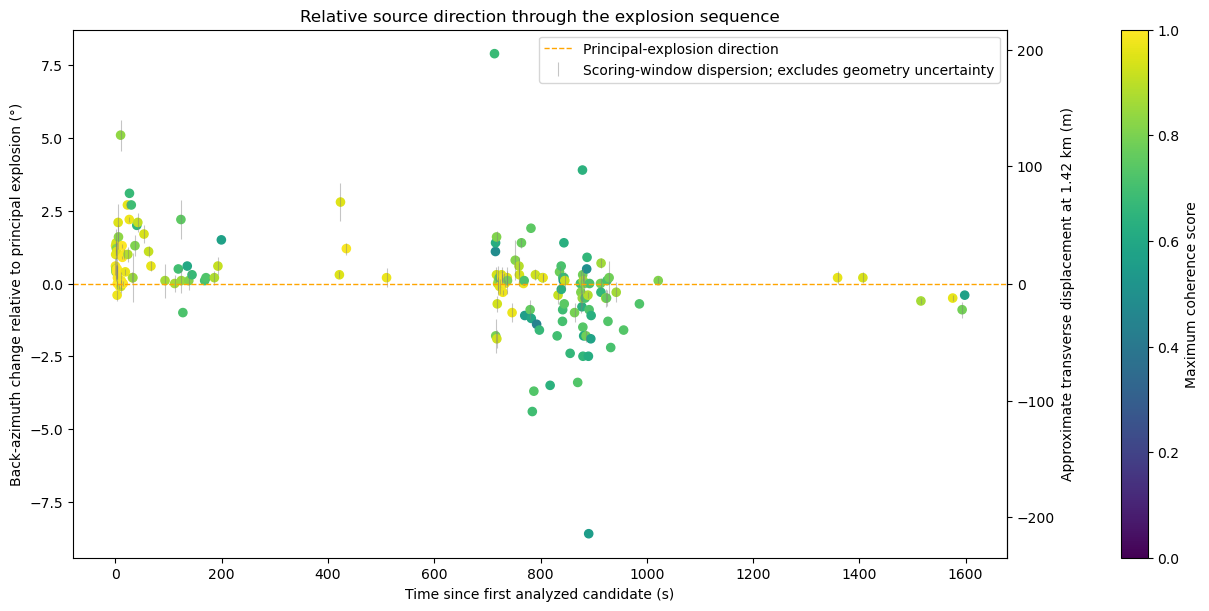

,event_number,reference_time_utc,best_back_azimuth_deg,relative_back_azimuth_deg,approximate_cross_range_m,best_apparent_speed_mps,maximum_coherence_score,solution_quality_class
0,1,2016-09-01 13:07:15.927133560+00:00,200.9,0.6,14.869560,352.5,0.979982,A_high_quality
1,2,2016-09-01 13:07:16.057133436+00:00,201.6,1.3,32.221732,355.5,0.961110,A_high_quality
2,3,2016-09-01 13:07:16.255000114+00:00,201.3,1.0,24.784211,352.5,0.957236,A_high_quality
3,4,2016-09-01 13:07:16.447066784+00:00,200.8,0.5,12.391162,340.5,0.872909,B_probable
4,5,2016-09-01 13:07:16.799566746+00:00,200.7,0.4,9.912839,359.0,0.806525,B_probable
...,...,...,...,...,...,...,...,...
148,149,2016-09-01 13:30:42.723999977+00:00,200.5,0.2,4.956359,354.5,0.939494,A_high_quality
149,150,2016-09-01 13:32:31.965133429+00:00,199.7,-0.6,-14.869560,355.0,0.865294,B_probable
150,151,2016-09-01 13:33:31.789000034+00:00,199.8,-0.5,-12.391162,353.5,0.961374,A_high_quality
151,152,2016-09-01 13:33:49.516566753+00:00,199.4,-0.9,-22.305360,345.0,0.786974,B_probable


In [10]:
principal_back_azimuth_deg = float(principal_result.iloc[0]["best_back_azimuth_deg"])
sequence_start_epoch_s = float(planar_results["reference_time_epoch_s"].min())
planar_results["sequence_time_s"] = planar_results["reference_time_epoch_s"] - sequence_start_epoch_s
planar_results["relative_back_azimuth_deg"] = wrapped_angle_difference_deg(
    planar_results["best_back_azimuth_deg"], principal_back_azimuth_deg
)
planar_results["approximate_cross_range_m"] = ARRAY_TO_SOURCE_REFERENCE_RANGE_M * np.tan(
    np.deg2rad(planar_results["relative_back_azimuth_deg"])
)
planar_results.to_csv(OUTPUT_ROOT / "planar_array_results.csv", index=False)

def degrees_to_metres(angle_deg):
    return ARRAY_TO_SOURCE_REFERENCE_RANGE_M * np.tan(np.deg2rad(angle_deg))

def metres_to_degrees(distance_m):
    return np.rad2deg(np.arctan(np.asarray(distance_m) / ARRAY_TO_SOURCE_REFERENCE_RANGE_M))

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
scatter = ax.scatter(
    planar_results["sequence_time_s"],
    planar_results["relative_back_azimuth_deg"],
    c=planar_results["maximum_coherence_score"],
    cmap="viridis", vmin=0, vmax=1, s=35,
)
if RUN_WINDOW_STABILITY:
    ax.errorbar(
        planar_results["sequence_time_s"],
        planar_results["relative_back_azimuth_deg"],
        yerr=planar_results["stability_back_azimuth_std_deg"],
        fmt="none", ecolor="0.5", alpha=0.45, lw=0.8,
        label="Scoring-window dispersion; excludes geometry uncertainty",
    )
ax.axhline(0, color="orange", ls="--", lw=1, label="Principal-explosion direction")
ax.set(
    xlabel="Time since first analyzed candidate (s)",
    ylabel="Back-azimuth change relative to principal explosion (°)",
    title="Relative source direction through the explosion sequence",
)
secondary = ax.secondary_yaxis("right", functions=(degrees_to_metres, metres_to_degrees))
secondary.set_ylabel("Approximate transverse displacement at 1.42 km (m)")
ax.legend()
fig.colorbar(scatter, ax=ax, label="Maximum coherence score")
fig.savefig(OUTPUT_ROOT / "relative_back_azimuth_cross_range_vs_time.pdf", dpi=240, bbox_inches="tight")
plt.show()

display(planar_results[[
    "event_number", "reference_time_utc", "best_back_azimuth_deg",
    "relative_back_azimuth_deg", "approximate_cross_range_m",
    "best_apparent_speed_mps", "maximum_coherence_score", "solution_quality_class",
]])


## Catalogue summaries and Notebook 09 handoff

Inspect continuous quality metrics rather than treating the provisional A/B/C labels
as immutable scientific classes. The refined planar results remain the direct input
to fixed-source and local-grid spherical analyses.


Solution-quality class counts:


,events
class,
A_HIGH_QUALITY,51
B_PROBABLE,45
C_WEAK_OR_BROAD,57



Refined planar-solution summary statistics:


,subset,event_count,minimum_coherence,median_coherence,maximum_coherence,weighted_back_azimuth_deg,weighted_back_azimuth_std_deg,median_back_azimuth_deg,weighted_apparent_speed_mps,weighted_apparent_speed_std_mps,median_apparent_speed_mps
0,All events,153,0.439,0.813,0.998,200.442,1.510,200.5,352.92,19.27,352.5
1,Coherence ≥ 0.90,55,0.908,0.962,0.998,200.774,0.849,200.6,351.96,7.09,352.5
2,Quality A,51,0.908,0.963,0.998,200.725,0.703,200.5,351.98,3.85,352.5
3,Quality A+B,96,0.750,0.926,0.998,200.696,0.969,200.5,352.04,11.93,352.5



Compact subset summaries:
  All events: n=153; coherence median=0.813 (range 0.439–0.998); weighted BAZ=200.44 ± 1.51°; median BAZ=200.50°; weighted speed=352.9 ± 19.3 m/s; median speed=352.5 m/s
  Coherence ≥ 0.90: n=55; coherence median=0.962 (range 0.908–0.998); weighted BAZ=200.77 ± 0.85°; median BAZ=200.60°; weighted speed=352.0 ± 7.1 m/s; median speed=352.5 m/s
  Quality A: n=51; coherence median=0.963 (range 0.908–0.998); weighted BAZ=200.73 ± 0.70°; median BAZ=200.50°; weighted speed=352.0 ± 3.8 m/s; median speed=352.5 m/s
  Quality A+B: n=96; coherence median=0.926 (range 0.750–0.998); weighted BAZ=200.70 ± 0.97°; median BAZ=200.50°; weighted speed=352.0 ± 11.9 m/s; median speed=352.5 m/s

Saved summary table: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/planar_refined_solution_summaries.csv


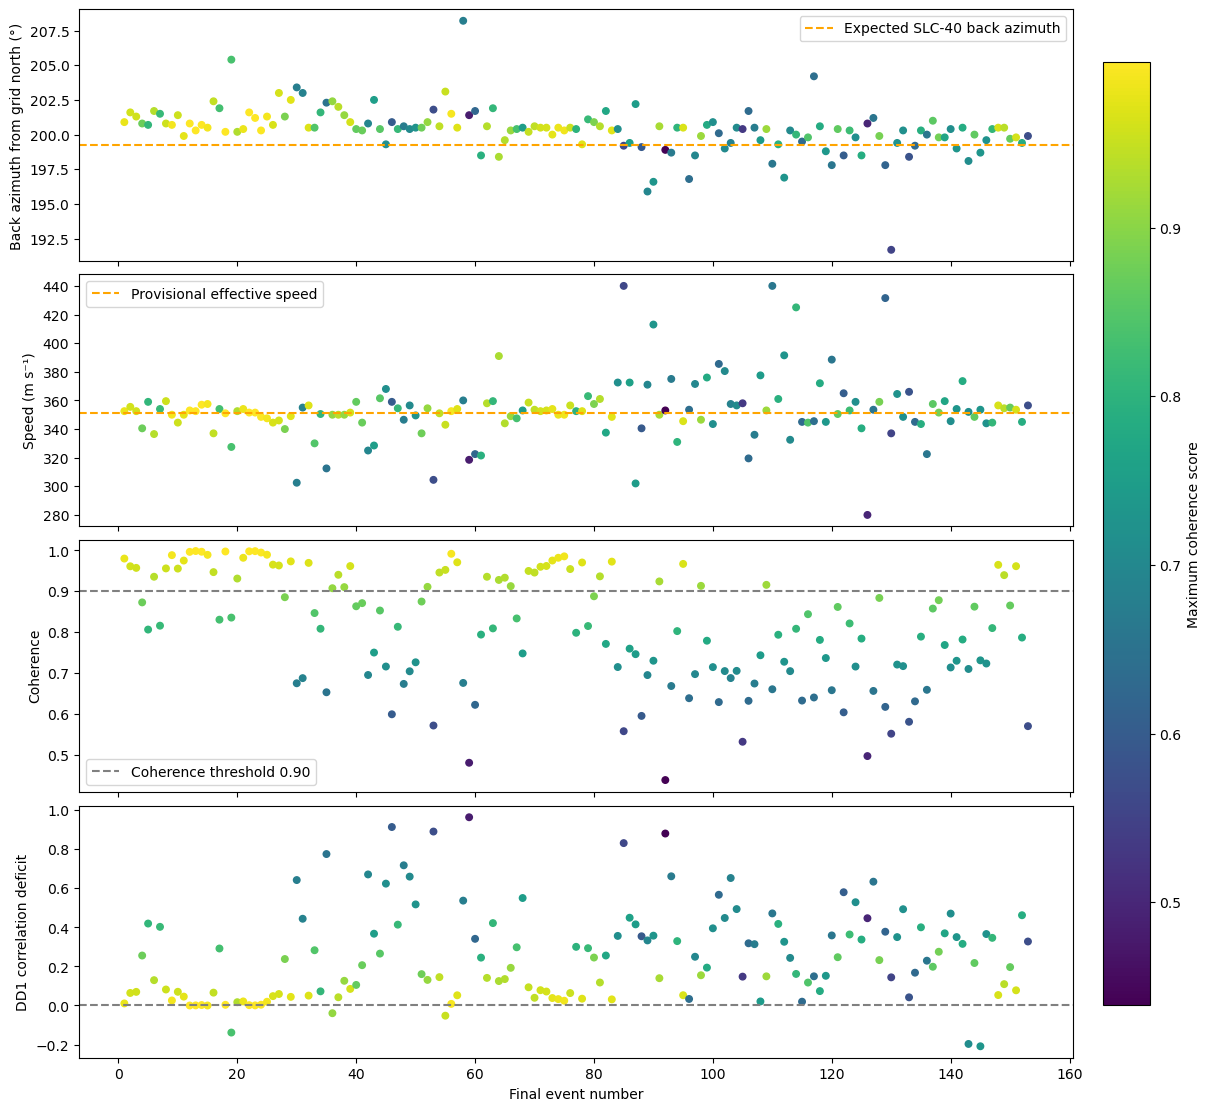

Saved summary figure: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/planar_catalogue_summary.pdf


In [11]:
# ---------------------------------------------------------------------
# Catalogue-level plot and refined-solution subset summaries
# ---------------------------------------------------------------------

SUMMARY_COHERENCE_THRESHOLD = 0.90


def weighted_mean_and_std(values, weights):
    """Weighted arithmetic mean and population standard deviation."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )
    values = values[valid]
    weights = weights[valid]

    if values.size == 0:
        return np.nan, np.nan

    weighted_mean = np.average(
        values,
        weights=weights,
    )
    weighted_variance = np.average(
        (values - weighted_mean) ** 2,
        weights=weights,
    )

    return (
        float(weighted_mean),
        float(np.sqrt(weighted_variance)),
    )


def weighted_circular_mean_and_std_deg(
    angles_deg,
    weights,
):
    """Weighted circular mean and circular standard deviation."""
    angles_deg = np.asarray(
        angles_deg,
        dtype=float,
    )
    weights = np.asarray(
        weights,
        dtype=float,
    )

    valid = (
        np.isfinite(angles_deg)
        & np.isfinite(weights)
        & (weights > 0)
    )
    angles_deg = angles_deg[valid]
    weights = weights[valid]

    if angles_deg.size == 0:
        return np.nan, np.nan

    angles_rad = np.deg2rad(angles_deg)

    weighted_sine = np.average(
        np.sin(angles_rad),
        weights=weights,
    )
    weighted_cosine = np.average(
        np.cos(angles_rad),
        weights=weights,
    )

    mean_rad = np.arctan2(
        weighted_sine,
        weighted_cosine,
    )
    mean_deg = np.rad2deg(mean_rad) % 360.0

    resultant_length = np.hypot(
        weighted_sine,
        weighted_cosine,
    )
    resultant_length = np.clip(
        resultant_length,
        0.0,
        1.0,
    )

    circular_std_deg = (
        np.rad2deg(
            np.sqrt(
                -2.0 * np.log(resultant_length)
            )
        )
        if resultant_length > 0
        else np.nan
    )

    return (
        float(mean_deg),
        float(circular_std_deg),
    )


def summarize_refined_subset(
    results,
    *,
    subset_name,
    selection_mask,
    selection_description,
):
    """Calculate weighted and unweighted statistics for one subset."""
    required_columns = [
        "best_back_azimuth_deg",
        "best_apparent_speed_mps",
        "maximum_coherence_score",
    ]

    subset = (
        results.loc[selection_mask]
        .dropna(subset=required_columns)
        .copy()
    )

    if subset.empty:
        return {
            "subset": subset_name,
            "selection": selection_description,
            "event_count": 0,
            "weight_sum": 0.0,
            "minimum_coherence": np.nan,
            "median_coherence": np.nan,
            "maximum_coherence": np.nan,
            "weighted_back_azimuth_deg": np.nan,
            "weighted_back_azimuth_std_deg": np.nan,
            "weighted_apparent_speed_mps": np.nan,
            "weighted_apparent_speed_std_mps": np.nan,
            "median_back_azimuth_deg": np.nan,
            "median_apparent_speed_mps": np.nan,
        }

    weights = subset[
        "maximum_coherence_score"
    ].to_numpy(float)

    weighted_speed, weighted_speed_std = (
        weighted_mean_and_std(
            subset["best_apparent_speed_mps"],
            weights,
        )
    )

    weighted_azimuth, weighted_azimuth_std = (
        weighted_circular_mean_and_std_deg(
            subset["best_back_azimuth_deg"],
            weights,
        )
    )

    coherence = subset[
        "maximum_coherence_score"
    ]

    return {
        "subset": subset_name,
        "selection": selection_description,
        "event_count": int(len(subset)),
        "weight_sum": float(weights.sum()),
        "minimum_coherence": float(
            coherence.min()
        ),
        "median_coherence": float(
            coherence.median()
        ),
        "maximum_coherence": float(
            coherence.max()
        ),
        "weighted_back_azimuth_deg": (
            weighted_azimuth
        ),
        "weighted_back_azimuth_std_deg": (
            weighted_azimuth_std
        ),
        "weighted_apparent_speed_mps": (
            weighted_speed
        ),
        "weighted_apparent_speed_std_mps": (
            weighted_speed_std
        ),
        "median_back_azimuth_deg": float(
            subset[
                "best_back_azimuth_deg"
            ].median()
        ),
        "median_apparent_speed_mps": float(
            subset[
                "best_apparent_speed_mps"
            ].median()
        ),
    }


if planar_results.empty:
    print(
        "No successful planar-array solutions "
        "are available to summarize."
    )

else:
    # Normalize quality labels once.
    quality_class = (
        planar_results["solution_quality_class"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    is_quality_a = quality_class.eq("A_HIGH_QUALITY")
    is_quality_b = quality_class.eq("B_PROBABLE")

    # Define all requested subsets in one place.
    subset_definitions = [
        {
            "subset_name": "All events",
            "selection_mask": pd.Series(
                True,
                index=planar_results.index,
            ),
            "selection_description": (
                "All successfully analyzed events"
            ),
        },
        {
            "subset_name": "Coherence ≥ 0.90",
            "selection_mask": (
                planar_results[
                    "maximum_coherence_score"
                ]
                >= SUMMARY_COHERENCE_THRESHOLD
            ),
            "selection_description": (
                "Maximum coherence score ≥ "
                f"{SUMMARY_COHERENCE_THRESHOLD:.2f}"
            ),
        },
        {
            "subset_name": "Quality A",
            "selection_mask": is_quality_a,
            "selection_description": (
                "Solution-quality class A_high_quality"
            ),
        },
        {
            "subset_name": "Quality A+B",
            "selection_mask": is_quality_a | is_quality_b,
            "selection_description": (
                "Solution-quality class A_high_quality or B_probable"
            ),
        },
    ]

    solution_summaries = pd.DataFrame([
        summarize_refined_subset(
            planar_results,
            **definition,
        )
        for definition in subset_definitions
    ])

    # -------------------------------------------------------------
    # Print and display summary statistics in the notebook
    # -------------------------------------------------------------
    print("Solution-quality class counts:")

    quality_counts = (
        quality_class
        .value_counts(dropna=False)
        .rename_axis("class")
        .to_frame("events")
        .sort_index()
    )
    display(quality_counts)

    print(
        "\nRefined planar-solution "
        "summary statistics:"
    )

    summary_display_columns = [
        "subset",
        "event_count",
        "minimum_coherence",
        "median_coherence",
        "maximum_coherence",
        "weighted_back_azimuth_deg",
        "weighted_back_azimuth_std_deg",
        "median_back_azimuth_deg",
        "weighted_apparent_speed_mps",
        "weighted_apparent_speed_std_mps",
        "median_apparent_speed_mps",
    ]

    display(
        solution_summaries[
            summary_display_columns
        ].round({
            "minimum_coherence": 3,
            "median_coherence": 3,
            "maximum_coherence": 3,
            "weighted_back_azimuth_deg": 3,
            "weighted_back_azimuth_std_deg": 3,
            "median_back_azimuth_deg": 3,
            "weighted_apparent_speed_mps": 2,
            "weighted_apparent_speed_std_mps": 2,
            "median_apparent_speed_mps": 2,
        })
    )

    print("\nCompact subset summaries:")

    for row in solution_summaries.itertuples(
        index=False
    ):
        if row.event_count == 0:
            print(
                f"  {row.subset}: no events"
            )
            continue

        print(
            f"  {row.subset}: "
            f"n={row.event_count}; "
            f"coherence median="
            f"{row.median_coherence:.3f} "
            f"(range "
            f"{row.minimum_coherence:.3f}–"
            f"{row.maximum_coherence:.3f}); "
            f"weighted BAZ="
            f"{row.weighted_back_azimuth_deg:.2f} "
            f"± "
            f"{row.weighted_back_azimuth_std_deg:.2f}°; "
            f"median BAZ="
            f"{row.median_back_azimuth_deg:.2f}°; "
            f"weighted speed="
            f"{row.weighted_apparent_speed_mps:.1f} "
            f"± "
            f"{row.weighted_apparent_speed_std_mps:.1f} m/s; "
            f"median speed="
            f"{row.median_apparent_speed_mps:.1f} m/s"
        )

    summary_file = (
        OUTPUT_ROOT
        / "planar_refined_solution_summaries.csv"
    )
    solution_summaries.to_csv(
        summary_file,
        index=False,
    )

    print(
        "\nSaved summary table:",
        summary_file,
    )

    # -------------------------------------------------------------
    # Display and save the four-panel catalogue summary plot
    # -------------------------------------------------------------
    coherence = planar_results[
        "maximum_coherence_score"
    ]

    norm = plt.Normalize(
        vmin=float(coherence.min()),
        vmax=float(coherence.max()),
    )

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(12, 11),
        sharex=True,
        constrained_layout=True,
    )

    scatter_kwargs = {
        "c": coherence,
        "cmap": "viridis",
        "norm": norm,
        "s": 22,
    }

    scatter = axes[0].scatter(
        planar_results["event_number"],
        planar_results[
            "best_back_azimuth_deg"
        ],
        **scatter_kwargs,
    )
    axes[0].axhline(
        EXPECTED_SLC40_BACK_AZIMUTH_DEG,
        color="orange",
        linestyle="--",
        label="Expected SLC-40 back azimuth",
    )
    axes[0].set_ylabel(
        "Back azimuth from grid north (°)"
    )
    axes[0].legend(loc="best")

    axes[1].scatter(
        planar_results["event_number"],
        planar_results[
            "best_apparent_speed_mps"
        ],
        **scatter_kwargs,
    )
    axes[1].axhline(
        PROVISIONAL_EFFECTIVE_SPEED_MPS,
        color="orange",
        linestyle="--",
        label="Provisional effective speed",
    )
    axes[1].set_ylabel(
        "Speed (m s⁻¹)"
    )
    axes[1].legend(loc="best")

    axes[2].scatter(
        planar_results["event_number"],
        coherence,
        **scatter_kwargs,
    )
    axes[2].axhline(
        SUMMARY_COHERENCE_THRESHOLD,
        color="0.5",
        linestyle="--",
        label=(
            f"Coherence threshold "
            f"{SUMMARY_COHERENCE_THRESHOLD:.2f}"
        ),
    )
    axes[2].set_ylabel("Coherence")
    axes[2].legend(loc="best")

    axes[3].scatter(
        planar_results["event_number"],
        planar_results[
            "dd1_correlation_deficit"
        ],
        **scatter_kwargs,
    )
    axes[3].axhline(
        0.0,
        color="0.5",
        linestyle="--",
    )
    axes[3].set_ylabel(
        "DD1 correlation deficit"
    )
    axes[3].set_xlabel(
        "Final event number"
    )

    colorbar = fig.colorbar(
        scatter,
        ax=axes,
        location="right",
        shrink=0.90,
        pad=0.02,
    )
    colorbar.set_label(
        "Maximum coherence score"
    )

    summary_figure_file = (
        OUTPUT_ROOT
        / "planar_catalogue_summary.pdf"
    )
    fig.savefig(
        summary_figure_file,
        dpi=220,
        bbox_inches="tight",
    )

    # Display the plot in the notebook.
    plt.show()

    print(
        "Saved summary figure:",
        summary_figure_file,
    )

## Combined 04b Bartlett and 08 refined planar-array figure

This publication-oriented figure uses the refined time-domain back azimuth
and apparent velocity from Notebook 080 together with the empirically
calibrated event-centred Bartlett F statistic from Notebook 040. Times are
reduced from the DD2 arrival time to estimated source UTC before phase
intervals are drawn.


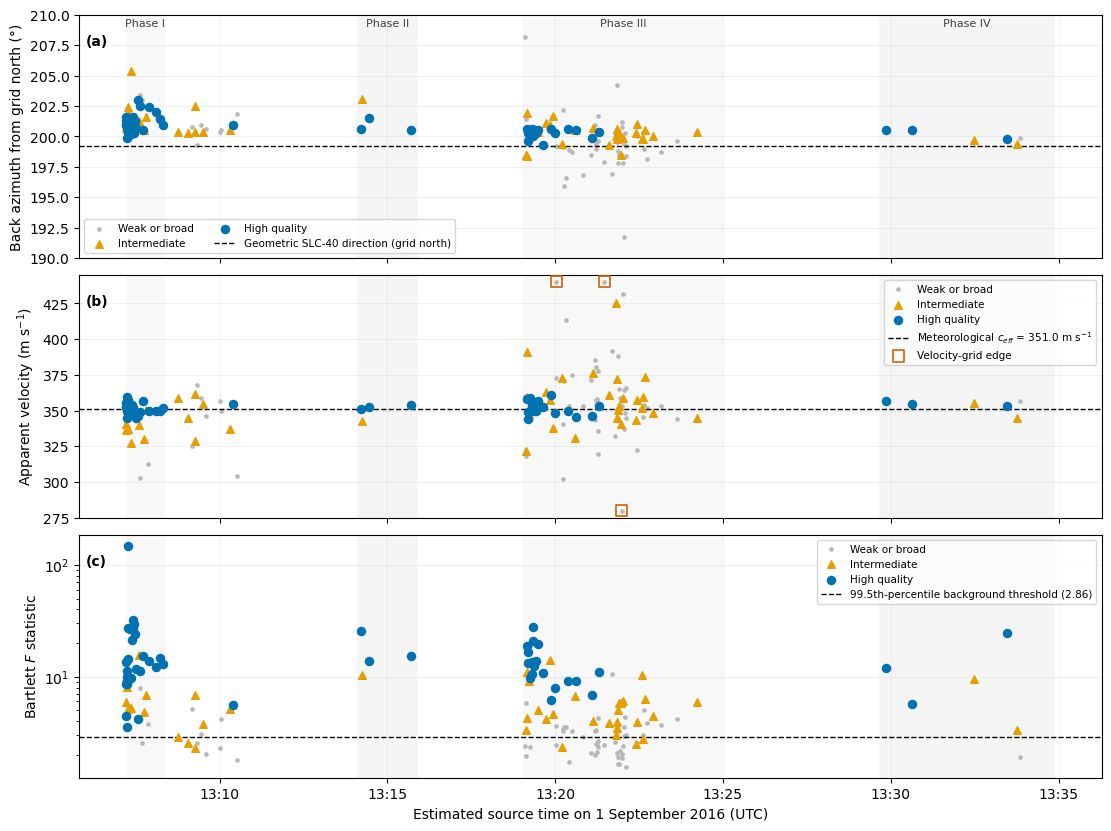

Saved /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/combined_04b_08_array_summary.png
Saved /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/combined_04b_08_array_summary.pdf
Saved /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/080_analyze_planar_array_propagation/combined_04b_08_array_results.csv


In [12]:
from datetime import timezone
from matplotlib.dates import DateFormatter

BARTLETT_OUTPUT_CANDIDATES = [
    config.NB040_DIR / "event_centred_bartlett_validation.csv",
]
BARTLETT_METADATA_CANDIDATES = [
    config.NB040_DIR / "infrapy_validation_metadata.json",
]

bartlett_file = next(
    (path for path in BARTLETT_OUTPUT_CANDIDATES if path.exists()),
    None,
)
bartlett_metadata_file = next(
    (path for path in BARTLETT_METADATA_CANDIDATES if path.exists()),
    None,
)
if bartlett_file is None or bartlett_metadata_file is None:
    raise FileNotFoundError(
        "Run Notebook 040 before generating the combined array figure"
    )

bartlett = pd.read_csv(bartlett_file)
bartlett_metadata = json.loads(bartlett_metadata_file.read_text())
required_bartlett_columns = {"final_event_number", "f_stat"}
missing = required_bartlett_columns.difference(bartlett.columns)
if missing:
    raise KeyError(f"Bartlett table lacks {sorted(missing)}")

combined = planar_results.merge(
    bartlett[[
        "final_event_number",
        "f_stat",
        "above_empirical_background_threshold",
        "back_azimuth_grid_edge",
        "trace_velocity_grid_edge",
    ]],
    left_on="event_number",
    right_on="final_event_number",
    how="left",
    validate="one_to_one",
)
if len(combined) != 153 or combined["f_stat"].isna().any():
    raise RuntimeError("Combined 04b/08 table is not complete for 153 events")

geometry_channel_column = choose_column(geometry, ["channel", "sensor", "label"])
dd2_rows = geometry.loc[
    geometry[geometry_channel_column].astype(str).str.upper().eq("DD2")
]
if len(dd2_rows) != 1 or "distance_m" not in geometry.columns:
    raise RuntimeError("Cannot determine the DD2 source distance")
dd2_travel_time_s = (
    float(dd2_rows.iloc[0]["distance_m"])
    / SOURCE_REDUCTION_SPEED_MPS
)
combined["estimated_source_epoch_s"] = (
    combined["reference_time_epoch_s"] - dd2_travel_time_s
)
combined["estimated_source_utc"] = pd.to_datetime(
    combined["estimated_source_epoch_s"], unit="s", utc=True
)

# Require the shared definition; never fall back to notebook-specific dates.
configured_phases = config.OVERVIEW_PHASE_INTERVALS
if not configured_phases:
    raise ValueError("Shared overview phase intervals are required")
phase_intervals = [
    (str(label), pd.Timestamp(str(start)), pd.Timestamp(str(end)))
    for label, start, end in configured_phases
]
for i, (label, start, end) in enumerate(phase_intervals):
    if start >= end or (i and start < phase_intervals[i-1][2]):
        raise ValueError("Phase intervals must be ordered, positive and nonoverlapping")

quality_styles = {
    "C_weak_or_broad": dict(color="0.72", marker=".", s=22,
                                 label="Weak or broad", zorder=2),
    "B_probable": dict(color="#E69F00", marker="^", s=30,
                       label="Intermediate", zorder=3),
    "A_high_quality": dict(color="#0072B2", marker="o", s=34,
                           label="High quality", zorder=4),
}

def scatter_by_quality(axis, y_column):
    for quality, style in quality_styles.items():
        subset = combined.loc[combined["solution_quality_class"].eq(quality)]
        axis.scatter(
            subset["estimated_source_utc"], subset[y_column], **style
        )

def add_phase_shading(axis, *, label_phases=False):
    for index, (label, start, end) in enumerate(phase_intervals):
        axis.axvspan(start, end, color="0.5", alpha=0.055 + 0.025 * (index % 2),
                     linewidth=0)
        if label_phases:
            axis.text(
                start + (end - start) / 2, 0.985, label,
                transform=axis.get_xaxis_transform(), ha="center", va="top",
                fontsize=8, color="0.25",
            )

fig, axes = plt.subplots(3, 1, figsize=(11.0, 8.2), sharex=True,
                         constrained_layout=True)
scatter_by_quality(axes[0], "best_back_azimuth_deg")
axes[0].axhline(EXPECTED_SLC40_BACK_AZIMUTH_DEG, color="black", ls="--", lw=1.0,
                label="Geometric SLC-40 direction (grid north)")
axes[0].set_ylabel("Back azimuth from grid north (°)")
axes[0].set_ylim(190, 210)
axes[0].legend(ncol=2, fontsize=7.5, loc="lower left")

scatter_by_quality(axes[1], "best_apparent_speed_mps")
axes[1].axhline(PROVISIONAL_EFFECTIVE_SPEED_MPS, color="black", ls="--", lw=1.0,
                label=f"Meteorological $c_{{eff}}$ = {PROVISIONAL_EFFECTIVE_SPEED_MPS:.1f} m s$^{{-1}}$")
edge = combined["best_on_speed_edge"].astype(bool)
axes[1].scatter(combined.loc[edge, "estimated_source_utc"],
                combined.loc[edge, "best_apparent_speed_mps"],
                facecolors="none", edgecolors="#D55E00", marker="s", s=65,
                linewidths=1.2, label="Velocity-grid edge", zorder=6)
axes[1].set_ylabel("Apparent velocity (m s$^{-1}$)")
axes[1].set_ylim(275, 445)
axes[1].legend(fontsize=7.5, loc="upper right")

scatter_by_quality(axes[2], "f_stat")
empirical_f_threshold = float(bartlett_metadata["empirical_f_threshold"])
axes[2].axhline(empirical_f_threshold, color="black", ls="--", lw=1.0,
                label=f"99.5th-percentile background threshold ({empirical_f_threshold:.2f})")
axes[2].set_yscale("log")
axes[2].set_ylabel("Bartlett $F$ statistic")
axes[2].set_xlabel("Estimated source time on 1 September 2016 (UTC)")
axes[2].legend(fontsize=7.5, loc="upper right")

for index, axis in enumerate(axes):
    add_phase_shading(axis, label_phases=index == 0)
    axis.grid(True, alpha=0.20, linewidth=0.6)
    axis.text(0.006, 0.92, f"({chr(97 + index)})", transform=axis.transAxes,
              fontweight="bold", va="top")
axes[-1].xaxis.set_major_formatter(DateFormatter("%H:%M", tz=timezone.utc))

combined_figure_png = OUTPUT_ROOT / "combined_04b_08_array_summary.png"
combined_figure_pdf = OUTPUT_ROOT / "combined_04b_08_array_summary.pdf"
combined_table_file = OUTPUT_ROOT / "combined_04b_08_array_results.csv"
fig.savefig(combined_figure_png, dpi=300, bbox_inches="tight")
fig.savefig(combined_figure_pdf, bbox_inches="tight")
combined.to_csv(combined_table_file, index=False)
plt.show()
print("Saved", combined_figure_png)
print("Saved", combined_figure_pdf)
print("Saved", combined_table_file)


## Conditional sensor-position sensitivity
These deterministic fixed-delay scenarios show sensitivity to relative geometry.
They do not supply uncertainty bounds or alter the nominal results/quality classes.
Holding DD2 fixed preserves the reference convention; it does not establish that
DD2 has no position error. Coupled errors and full waveform re-inversion remain open.


,min_baz_change,max_baz_change,min_speed_change,max_speed_change
offset_radius_m,,,,
0.0,0.000000,0.000000,0.000000,0.000000
1.0,-2.090447,2.035527,-11.835303,11.867844
2.0,-4.232286,4.123160,-23.637466,23.767616


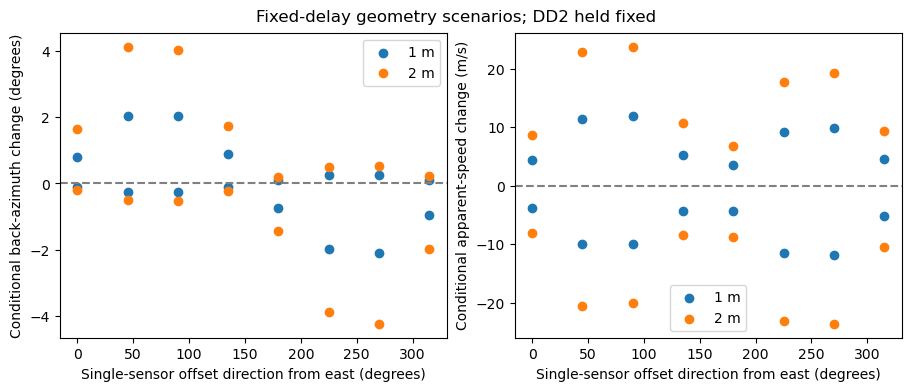

1779

In [13]:
# Conditional sensitivity of the principal solution to sensor positions.
# Hold nominal inferred DD1/DD3-to-DD2 delays fixed; solve slowness exactly.
# This does not re-invert waveforms or assert a position-error distribution.
principal = planar_results.loc[planar_results.event_number.eq(PRINCIPAL_EXPLOSION_EVENT_NUMBER)]
if len(principal) != 1:
    raise ValueError("Principal representative solution is required for geometry sensitivity")
principal = principal.iloc[0]
xy = array_geometry.loc[list(CHANNELS), ["east_m", "north_m"]].to_numpy(float)
ref = list(CHANNELS).index("DD2")
others = [i for i in range(len(CHANNELS)) if i != ref]
baz = float(principal.best_back_azimuth_deg)
speed = float(principal.best_apparent_speed_mps)
nominal_slowness = -np.array([np.sin(np.deg2rad(baz)), np.cos(np.deg2rad(baz))]) / speed
fixed_delays = (xy[others] - xy[ref]) @ nominal_slowness
scenarios = [("nominal", 0.0, 0.0, xy.copy())]
for radius in (1.0, 2.0):
    for sensor_index in others:
        for direction in np.arange(0.0, 360.0, 45.0):
            perturbed = xy.copy()
            perturbed[sensor_index] += radius * np.array([np.cos(np.deg2rad(direction)), np.sin(np.deg2rad(direction))])
            scenarios.append((CHANNELS[sensor_index], radius, direction, perturbed))
rows = []
for sensor, radius, direction, positions in scenarios:
    matrix = positions[others] - positions[ref]
    slowness = np.linalg.solve(matrix, fixed_delays)
    conditional_speed = 1.0 / np.linalg.norm(slowness)
    conditional_baz = np.rad2deg(np.arctan2(-slowness[0], -slowness[1])) % 360
    rows.append({"representative_event_number": int(principal.event_number),
        "perturbed_sensor": sensor, "offset_radius_m": radius, "offset_direction_from_east_deg": direction,
        "conditional_back_azimuth_deg": conditional_baz, "conditional_speed_mps": conditional_speed,
        "back_azimuth_change_deg": (conditional_baz - baz + 180) % 360 - 180,
        "speed_change_mps": conditional_speed - speed,
        "baseline_matrix_condition_number": np.linalg.cond(matrix)})
geometry_sensitivity = pd.DataFrame(rows)
geometry_sensitivity.to_csv(OUTPUT_ROOT / "principal_conditional_geometry_sensitivity.csv", index=False)
display(geometry_sensitivity.groupby("offset_radius_m").agg(
    min_baz_change=("back_azimuth_change_deg", "min"), max_baz_change=("back_azimuth_change_deg", "max"),
    min_speed_change=("speed_change_mps", "min"), max_speed_change=("speed_change_mps", "max")))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for radius, subset in geometry_sensitivity.groupby("offset_radius_m"):
    if radius == 0: continue
    axes[0].scatter(subset.offset_direction_from_east_deg, subset.back_azimuth_change_deg, label=f"{radius:g} m")
    axes[1].scatter(subset.offset_direction_from_east_deg, subset.speed_change_mps, label=f"{radius:g} m")
for axis in axes:
    axis.axhline(0, color="0.5", ls="--");axis.set_xlabel("Single-sensor offset direction from east (degrees)");axis.legend()
axes[0].set_ylabel("Conditional back-azimuth change (degrees)")
axes[1].set_ylabel("Conditional apparent-speed change (m/s)")
fig.suptitle("Fixed-delay geometry scenarios; DD2 held fixed")
fig.savefig(OUTPUT_ROOT / "principal_conditional_geometry_sensitivity.pdf", bbox_inches="tight")
plt.show()
(OUTPUT_ROOT / "planar_review_provenance.json").write_text(json.dumps({
    "notebook": "080_analyze_planar_array_propagation.ipynb",
    "geometry_file": str(geometry_file), "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "reference_channel": "DD2", "source_reduction_speed_mps": SOURCE_REDUCTION_SPEED_MPS,
    "azimuth_convention": "EPSG:32617 grid north; original nominal azimuth columns unchanged",
    "grid_convergence_deg": GRID_CONVERGENCE_DEG,
    "configured_geographic_baz_deg": CONFIGURED_GEOGRAPHIC_BAZ_DEG,
    "comparison_grid_baz_deg": EXPECTED_SLC40_BACK_AZIMUTH_DEG,
    "overview_phase_intervals": [(label, str(start), str(end)) for label,start,end in config.OVERVIEW_PHASE_INTERVALS],
    "geometry_scenarios": "Single DD1 or DD3 offset of 1 or 2 m in eight directions; DD2 and inferred delays held fixed",
    "geometry_scope": "Conditional scenarios, not confidence bounds; simultaneous sensor errors and waveform re-inversion omitted",
    "window_stability_scope": "Scoring-window repeatability at fixed coordinates, not total parameter uncertainty",
    "principal_row_scope": "Representative catalogue row 13; physical complex and named-event mapping require later review",
    "nominal_results_changed_by_geometry_diagnostic": False
}, indent=2) + "\n")
